# Project 1 · Activity 1 — 자동차 세부 차종 분류 데이터셋 분석

**목표**: 두 후보 데이터셋 **VMMRdb**와 **CompCars**를 실제 데이터로 비교해 프로젝트 데이터셋을 고르고, 과제 3~6단계(핵심 난제 · 초기 가설 · 개선 전략 · 시연 계획)를 데이터 근거로 정리한다.

> 이번 활동은 CNN 학습이 필요 없다. 아래 코드는 모두 **데이터를 세고, 측정하고, 들여다보는** 코드다.

| 파트 | 내용 |
|---|---|
| **0. 설정** | 경로(`path.md`), 공통 함수, 캐시 |
| **Part A. 데이터 분석** | A1 인덱스 → A2 라벨 품질 → A3 클래스 분포 → A4 계층 구조 → A5 이미지 속성 → A6 CompCars 전용 라벨 → A7 시각 검사 → A8 공통 제조사 → A9 비교표·선택 |
| **Part B. 실험 범위** | 50개 클래스 선정, 차체 유형 매핑, 중복 검사 |
| **Part C. 3~6단계 정리** | 핵심 난제, 가설(H0·H1·H2), 개선 전략, 평가 계획, 시연 시나리오, 참고문헌 |

- 그림은 `figures/`에, 표와 캐시는 `outputs/`에 저장된다. 보고서에 바로 쓸 수 있다.
- 무거운 스캔 결과는 CSV로 캐시되므로, 두 번째 실행부터는 빠르다. (`FORCE_REBUILD = True`로 다시 만들 수 있다.)

## 0. 설정

In [1]:
import os, re, math, random, hashlib, collections, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio
from PIL import Image
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font="AppleGothic", rc={"axes.unicode_minus": False})
mpl.rcParams.update({"font.family": "AppleGothic", "axes.unicode_minus": False,
                     "figure.dpi": 100, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
FORCE_REBUILD = False
FIG, OUT = Path("figures"), Path("outputs")
FIG.mkdir(exist_ok=True); OUT.mkdir(exist_ok=True)
C_VM, C_CC = "#2F6DB5", "#D9822B"          # 그림 전체에서 VMMRdb=파랑, CompCars=주황

def load_dataset_root(path_md="path.md"):
    """path.md 안의 따옴표 경로 중 실제로 존재하는 첫 번째 폴더를 쓴다 (팀원마다 한 줄씩 추가 가능)."""
    for cand in re.findall(r"""["']([^"']+)["']""", Path(path_md).read_text()):
        p = Path(cand).expanduser()
        if p.is_dir():
            return p
    raise FileNotFoundError("path.md에 존재하는 데이터셋 경로가 없습니다.")

ROOT = load_dataset_root()
VMMR, COMP = ROOT / "VMMRdb", ROOT / "COMPCAR"

def ls_visible(p):
    return sorted(x for x in os.listdir(p) if not x.startswith("."))

def cached(name, builder):
    f = OUT / f"{name}.csv"
    if f.exists() and not FORCE_REBUILD:
        return pd.read_csv(f, low_memory=False)
    df = builder(); df.to_csv(f, index=False)
    return df

def savefig(name):
    plt.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")

def norm(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

def gini(x):
    x = np.sort(np.asarray(x, dtype=float)); n = len(x)
    return float((2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))

def dist_stats(counts, name):
    v = np.asarray(counts)
    return {"단위": name, "클래스 수": len(v), "이미지 수": int(v.sum()), "최소": int(v.min()),
            "중앙값": float(np.median(v)), "평균": round(float(v.mean()), 1), "최대": int(v.max()),
            "최대/최소": round(v.max() / v.min(), 1), "Gini": round(gini(v), 3),
            "20장 미만 클래스": int((v < 20).sum()), "100장 이상 클래스": int((v >= 100).sum())}

print("데이터 경로:", ROOT)
print("VMMRdb:", VMMR.is_dir(), "| CompCars:", COMP.is_dir())

데이터 경로: /Users/yuhuiseon/Downloads/dataset
VMMRdb: True | CompCars: True


# Part A. 데이터 분석

## A1. 인덱스 구축 — 이미지 1장 = 1행

두 데이터셋은 저장 구조가 다르다. 그래서 먼저 같은 형태의 표(DataFrame)로 맞춘다.

| | VMMRdb | CompCars |
|---|---|---|
| 폴더 구조 | `{make}_{model}_{year}/*.jpg` | `image/{make_id}/{model_id}/{year}/*.jpg` |
| 라벨 출처 | 폴더 이름 | id → `misc/make_model_name.mat` |
| 추가 라벨 | 없음 (파일명에 원본 매물 제목) | 시점·bbox (`label/*.txt`), 차체 유형 (`misc/attributes.txt` + `car_type.mat`) |

In [2]:
def build_vmmr_index():
    rows = []
    for d in ls_visible(VMMR):
        p = VMMR / d
        if not p.is_dir():
            continue
        parts = d.split("_")
        make, model, year = parts[0], "_".join(parts[1:-1]), parts[-1]
        for f in ls_visible(p):
            rows.append((d, f, make, model, year))
    return pd.DataFrame(rows, columns=["folder", "file", "make", "model", "year"])

vm = cached("vmmr_index", build_vmmr_index)
vm["year"] = pd.to_numeric(vm["year"], errors="coerce")
vm["make_model"] = vm["make"] + "/" + vm["model"]
vm_folders = [d for d in ls_visible(VMMR) if (VMMR / d).is_dir()]
print(f"VMMRdb: 폴더 {len(vm_folders):,}개, 이미지 {len(vm):,}장")
vm.head()

VMMRdb: 폴더 9,170개, 이미지 285,086장


,folder,file,make,model,year,make_model
0,acura_cl_1997,1997 1997 CL Accura_00E0E_ai7YZfWPqcD_600x450.jpg,acura,cl,1997,acura/cl
1,acura_cl_1997,1997 1997 CL Accura_00X0X_chSlNKX6h7j_600x450.jpg,acura,cl,1997,acura/cl
2,acura_cl_1997,1997 1997 CL Accura_00n0n_f2kPzm5CpXr_600x450.jpg,acura,cl,1997,acura/cl
3,acura_cl_1997,1997 acura cl_00Q0Q_eKlwc4D1NrU_600x450.jpg,acura,cl,1997,acura/cl
4,acura_cl_1997,1997 acura cl_00p0p_lAPdeE6t8OG_600x450.jpg,acura,cl,1997,acura/cl


In [3]:
mm = sio.loadmat(COMP / "misc/make_model_name.mat")
cc_make_names = [x[0][0].strip() if len(x[0]) else "" for x in mm["make_names"]]
cc_model_names = [x[0][0].strip() if len(x[0]) else "" for x in mm["model_names"]]
car_types = [x[0] for x in sio.loadmat(COMP / "misc/car_type.mat")["types"][0]]
attr = pd.read_csv(COMP / "misc/attributes.txt", sep=" ")
attr["body_type"] = attr["type"].map(lambda t: car_types[t - 1] if t > 0 else "unknown")
VIEW = {-1: "unknown", 1: "front", 2: "rear", 3: "side", 4: "front-side", 5: "rear-side"}

def build_cc_index():
    rows, img = [], COMP / "image"
    for mk in ls_visible(img):
        for mo in ls_visible(img / mk):
            for y in ls_visible(img / mk / mo):
                for f in ls_visible(img / mk / mo / y):
                    rel = f"{mk}/{mo}/{y}/{f}"
                    lab = COMP / "label" / rel.replace(".jpg", ".txt")
                    vp, box = -1, [np.nan] * 4
                    if lab.exists():
                        t = lab.read_text().split()
                        vp, box = int(t[0]), [int(v) for v in t[2:6]]
                    rows.append((rel, int(mk), int(mo), y, vp, *box))
    return pd.DataFrame(rows, columns=["rel", "make_id", "model_id", "year", "viewpoint", "x1", "y1", "x2", "y2"])

cc = cached("compcars_index", build_cc_index)
cc["make"] = cc["make_id"].map(lambda i: cc_make_names[i - 1])
cc["model"] = cc["model_id"].map(lambda i: cc_model_names[i - 1])
cc = cc.merge(attr[["model_id", "body_type"]], on="model_id", how="left").fillna({"body_type": "unknown"})
cc["view"] = cc["viewpoint"].map(VIEW)
print(f"CompCars: 이미지 {len(cc):,}장, 제조사 {cc.make_id.nunique()}개, 모델 {cc.model_id.nunique():,}개")
cc.head()

CompCars: 이미지 136,726장, 제조사 163개, 모델 1,716개


,rel,make_id,model_id,year,viewpoint,x1,y1,x2,y2,make,model,body_type,view
0,1/1101/2011/07b90decb92ba6.jpg,1,1101,2011,1,124,33,674,480,ABT,ABT A3,unknown,front
1,1/1101/2011/2272c7d324cf79.jpg,1,1101,2011,4,52,153,849,506,ABT,ABT A3,unknown,front-side
2,1/1101/2011/3a62131af5fe8e.jpg,1,1101,2011,4,85,107,682,469,ABT,ABT A3,unknown,front-side
3,1/1101/2011/5133ca181b82af.jpg,1,1101,2011,2,91,23,759,551,ABT,ABT A3,unknown,rear
4,1/1101/2011/6632ec1c2f7f87.jpg,1,1101,2011,5,58,134,707,504,ABT,ABT A3,unknown,rear-side


## A2. 라벨 품질 감사 (VMMRdb)

VMMRdb는 Craigslist 중고차 매물 사진을 **폴더 이름으로 라벨링**한 데이터다. 그래서 라벨 품질을 먼저 확인한다.

1. **연식 이상치**: `1900`처럼 실제 연식일 수 없는 값이 있는가?
2. **빈 폴더**
3. **모델명 단위 불일치**: 같은 차가 `civic`과 `civic_coupe`처럼 두 클래스로 쪼개져 있는가?
4. **파일명 ↔ 폴더 라벨 교차 검증**: 파일명에는 원본 매물 제목(예: `2005 F-150 Ford Crew Cab_...`)이 남아 있다. 이것을 폴더 라벨과 비교해서 라벨 노이즈를 추정한다.

In [4]:
folder_years = pd.Series({d: d.split("_")[-1] for d in vm_folders})
fy = pd.to_numeric(folder_years, errors="coerce")
placeholder = fy[fy == 1900].index.tolist()
classic = fy[(fy < 1950) & (fy != 1900)].index.tolist()
empty = sorted(set(vm_folders) - set(vm["folder"]))

print(f"연식 1900 (자리표시값으로 추정) 폴더: {len(placeholder)}개 → {placeholder[:6]} ...")
print(f"1950년 이전 클래식카 폴더: {len(classic)}개 (예: {classic[:4]}) — Ford Model T 1913처럼 실제 연식일 수 있음")
print(f"빈 폴더: {empty}")
print(f"연식 1900 폴더의 이미지 수: {vm[vm.year == 1900].shape[0]:,}장")

연식 1900 (자리표시값으로 추정) 폴더: 14개 → ['acura_integra_1900', 'acura_mdx_1900', 'audi_a4_1900', 'chevrolet_s10_1900', 'chevrolet_silverado_1900', 'ford_f150_1900'] ...
1950년 이전 클래식카 폴더: 66개 (예: ['buick_roadmaster_1938', 'buick_roadmaster_1947', 'buick_special_1937', 'buick_special_1940']) — Ford Model T 1913처럼 실제 연식일 수 있음
빈 폴더: ['bmw_528_2013']
연식 1900 폴더의 이미지 수: 16장


In [5]:
# 같은 제조사 안에서 'base'와 'base_xxx' / 'base xxx'가 함께 존재하면 단위 불일치 후보
mm_counts = vm.groupby(["make", "model"]).size().rename("n").reset_index()
models_by_make = mm_counts.groupby("make")["model"].apply(set).to_dict()
variant_rows = []
for make, models in models_by_make.items():
    for m in models:
        for base in models:
            if base != m and (m.startswith(base + "_") or m.startswith(base + " ")):
                variant_rows.append((make, base, m))
variants = pd.DataFrame(variant_rows, columns=["make", "base", "variant"])
variants = (variants.merge(mm_counts.rename(columns={"model": "base", "n": "n_base"}), on=["make", "base"])
                    .merge(mm_counts.rename(columns={"model": "variant", "n": "n_variant"}), on=["make", "variant"])
                    .sort_values("n_variant", ascending=False))
VARIANT_SET = set(zip(variants.make, variants.variant))
print(f"단위 불일치 후보: {len(variants)}쌍, 변형 클래스 이미지 {variants.n_variant.sum():,}장")
variants.head(12)

단위 불일치 후보: 79쌍, 변형 클래스 이미지 7,119장


,make,base,variant,n_base,n_variant
34,honda,civic,civic_coupe,6895,1599
70,volkswagen,passat,passat_wagon,1828,477
33,honda,civic,civic_hatchback,6895,461
23,ford,mustang,mustang_gt,5775,398
37,infiniti,g35,g35_coupe,864,370
24,ford,mustang,mustang_convertible,5775,364
64,toyota,camry,camry_le,5311,332
32,honda,accord,accord_2 door,6472,241
41,jeep,wrangler,wrangler_unlimited,1481,228
21,chevrolet,silverado,silverado_3500,5294,197


In [6]:
MAKE_ALIAS = {"chevrolet": ["chevy", "chev"], "volkswagen": ["vw"], "mercedesbenz": ["mercedes", "benz"],
              "landrover": ["rangerover", "land"], "rollsroyce": ["rolls"]}

CL_PAT = re.compile(r"^(?P<title>.+)_[0-9A-Za-z]{5}_[0-9A-Za-z]{8,}_\d+x\d+\.jpe?g$")

def title_of(f):
    """Craigslist 원본 파일명(`제목_xxxxx_id_600x450.jpg`)이면 제목, 아니면 None"""
    m = CL_PAT.match(f)
    return m.group("title") if m else None

def check_row(r):
    t = norm(title_of(r.file))
    mk = norm(r.make)
    make_ok = mk in t or any(a in t for a in MAKE_ALIAS.get(mk, []))
    model_ok = norm(r.model.split("_")[0]) in t
    years = re.findall(r"(?:19|20)\d\d", title_of(r.file))
    year_ok = (str(int(r.year)) in years) if years and not np.isnan(r.year) else np.nan
    return make_ok, model_ok, year_ok

samp_all = vm.sample(20000, random_state=SEED)
samp = samp_all[samp_all.file.map(title_of).notna()]
print(f"샘플 20,000장 중 원본 매물 제목이 남아 있는 파일: {len(samp):,}장 ({len(samp) / len(samp_all):.1%}) — 이 파일들만 검사")
chk = pd.DataFrame([check_row(r) for r in samp.itertuples()], columns=["make_ok", "model_ok", "year_ok"], index=samp.index)
samp = samp.join(chk)
agree = {"제조사명 포함": samp.make_ok.mean(), "모델명 포함": samp.model_ok.mean(),
         "연식 일치 (파일명에 연식이 있는 경우)": samp.year_ok.dropna().astype(float).mean(),
         "제조사·모델 모두 불일치": (~samp.make_ok & ~samp.model_ok).mean()}
display(pd.Series(agree, name=f"비율 (제목 있는 {len(samp):,}장)").map("{:.1%}".format).to_frame())
print("모델명 불일치 예시 (파일명 제목 vs 폴더 라벨):")
display(samp.loc[~samp.model_ok, ["folder", "file"]].assign(file=lambda d: d.file.map(title_of)).head(10))

샘플 20,000장 중 원본 매물 제목이 남아 있는 파일: 7,919장 (39.6%) — 이 파일들만 검사


,"비율 (제목 있는 7,919장)"
제조사명 포함,95.9%
모델명 포함,95.3%
연식 일치 (파일명에 연식이 있는 경우),99.9%
제조사·모델 모두 불일치,0.3%


모델명 불일치 예시 (파일명 제목 vs 폴더 라벨):


,folder,file
28318,chevrolet_c-k1500_1991,1991 Chevrolet K1500
28518,chevrolet_c-k2500_1998,1998 Chevrolet K2500
100250,ford_f150_2003,2003 Ford F 250 super duty 4x4
228882,oldsmobile_eightyeight_1973,1973 oldsmobile delta 88
28403,chevrolet_c-k1500_1995,1995 chevy 1500
17707,buick_century_1999,1999 Buick Centuru
46712,chevrolet_montecarlo_1973,1973 chev monty carlo
82319,dodge_ram_2500_2004,2004 Dodge 2500
165553,infiniti_qx50_2010,2010 2010 Infiniti EX35
229177,oldsmobile_ninetyeight_1990,1990 Old mobile 98


**해석.** 파일명은 판매자가 자유롭게 쓴 제목이다. 그래서 불일치가 곧 라벨 오류는 아니다. 약어, 오타, 트림명만 쓴 경우가 있기 때문이다.

다만 **제조사와 모델이 모두 불일치하는 비율**은 라벨 노이즈의 대략적인 **상한**으로 볼 수 있다. 위 예시를 눈으로 보면 진짜 오류와 표기 차이를 구분할 수 있다.

이후 계획:
- 연식 1900 폴더는 연식을 합쳐 쓰므로 제조사-모델 라벨은 그대로 쓸 수 있다.
- 단위 불일치 클래스(`civic_coupe` 등)는 **실험 클래스 선정에서 제외**한다. (Part B)

## A3. 클래스 분포 — "클래스를 무엇으로 정의하느냐"에 따라 난이도가 달라진다

같은 데이터라도 클래스 단위(제조사 / 제조사-모델 / 제조사-모델-연식)에 따라 클래스 수와 불균형이 크게 달라진다.

- **Gini 계수**: 0이면 완전 균등, 1에 가까울수록 소수 클래스에 이미지가 몰려 있다.

In [7]:
cc["make_model"] = cc["make"] + "/" + cc["model"]
stats = pd.DataFrame([
    dist_stats(vm.groupby("make").size(), "VMMRdb · 제조사"),
    dist_stats(vm.groupby("make_model").size(), "VMMRdb · 제조사-모델"),
    dist_stats(vm.groupby("folder").size(), "VMMRdb · 제조사-모델-연식"),
    dist_stats(cc.groupby("make_id").size(), "CompCars · 제조사"),
    dist_stats(cc.groupby("model_id").size(), "CompCars · 모델"),
    dist_stats(cc.groupby(["model_id", "year"]).size(), "CompCars · 모델-연식"),
]).set_index("단위")
stats.to_csv(OUT / "class_distribution_stats.csv")
stats

,클래스 수,이미지 수,최소,중앙값,평균,최대,최대/최소,Gini,20장 미만 클래스,100장 이상 클래스
단위,,,,,,,,,,
VMMRdb · 제조사,75,285086,2,614.0,3801.1,41203,20601.5,0.773,22,42
VMMRdb · 제조사-모델,1175,285086,1,33.0,242.6,6895,6895.0,0.804,480,393
VMMRdb · 제조사-모델-연식,9169,285086,1,9.0,31.1,883,883.0,0.701,6029,722
CompCars · 제조사,163,136726,2,409.0,838.8,5720,2860.0,0.610,7,134
CompCars · 모델,1716,136726,1,95.0,79.7,303,303.0,0.331,268,841
CompCars · 모델-연식,4446,136726,1,26.0,30.8,167,167.0,0.434,1773,145


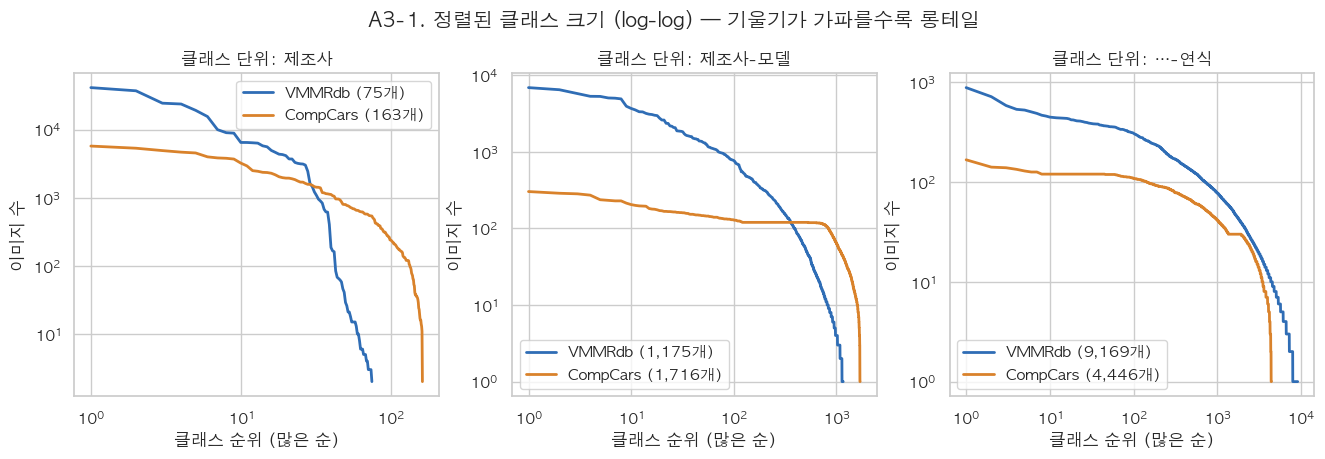

In [8]:
levels = [("제조사", vm.groupby("make").size(), cc.groupby("make_id").size()),
          ("제조사-모델", vm.groupby("make_model").size(), cc.groupby("model_id").size()),
          ("…-연식", vm.groupby("folder").size(), cc.groupby(["model_id", "year"]).size())]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (name, v, c) in zip(axes, levels):
    for s, col, lab in [(v, C_VM, "VMMRdb"), (c, C_CC, "CompCars")]:
        y = np.sort(s.values)[::-1]
        ax.plot(np.arange(1, len(y) + 1), y, color=col, lw=2, label=f"{lab} ({len(y):,}개)")
    ax.set(xscale="log", yscale="log", title=f"클래스 단위: {name}", xlabel="클래스 순위 (많은 순)", ylabel="이미지 수")
    ax.legend()
fig.suptitle("A3-1. 정렬된 클래스 크기 (log-log) — 기울기가 가파를수록 롱테일", y=1.03)
savefig("A3_1_rank_size"); plt.show()

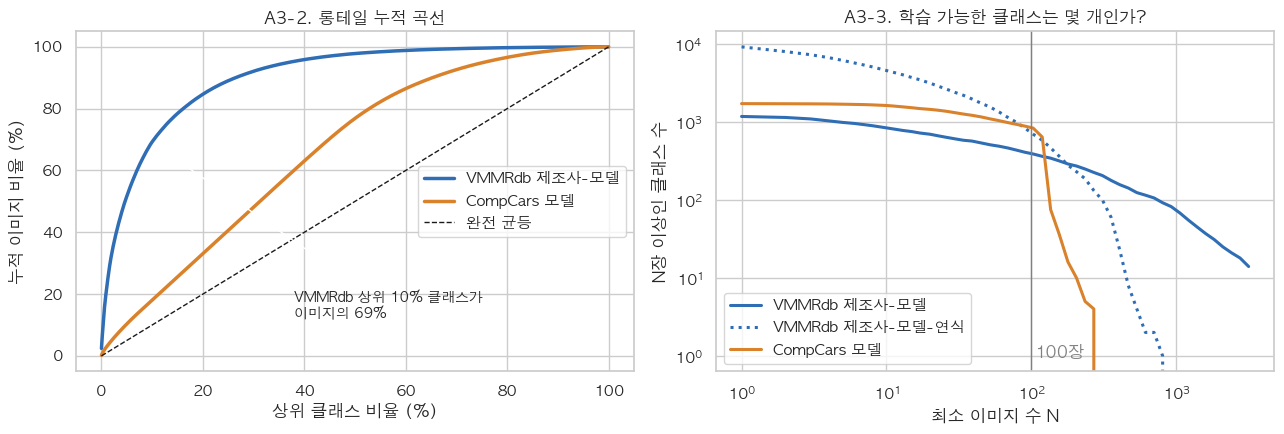

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
for s, col, lab in [(vm.groupby("make_model").size(), C_VM, "VMMRdb 제조사-모델"),
                    (cc.groupby("model_id").size(), C_CC, "CompCars 모델")]:
    y = np.sort(s.values)[::-1]
    ax.plot(np.linspace(0, 100, len(y)), np.cumsum(y) / y.sum() * 100, color=col, lw=2.5, label=lab)
ax.plot([0, 100], [0, 100], "k--", lw=1, label="완전 균등")
ax.set(xlabel="상위 클래스 비율 (%)", ylabel="누적 이미지 비율 (%)", title="A3-2. 롱테일 누적 곡선")
ax.legend(loc="center right")
v20 = np.sort(vm.groupby("make_model").size().values)[::-1]
top10 = v20[: max(1, len(v20) // 10)].sum() / v20.sum() * 100
ax.annotate(f"VMMRdb 상위 10% 클래스가\n이미지의 {top10:.0f}%", xy=(10, top10), xytext=(38, 12),
            arrowprops=dict(arrowstyle="->"), fontsize=10)

ax = axes[1]
th = np.unique(np.logspace(0, 3.5, 60).astype(int))
for s, col, lab in [(vm.groupby("make_model").size(), C_VM, "VMMRdb 제조사-모델"),
                    (vm.groupby("folder").size(), C_VM, "VMMRdb 제조사-모델-연식"),
                    (cc.groupby("model_id").size(), C_CC, "CompCars 모델")]:
    ls = ":" if "연식" in lab else "-"
    ax.plot(th, [(s.values >= t).sum() for t in th], color=col, ls=ls, lw=2.2, label=lab)
ax.axvline(100, color="gray", lw=1)
ax.text(105, 0.04, "100장", color="gray", transform=ax.get_xaxis_transform())
ax.set(xscale="log", yscale="log", xlabel="최소 이미지 수 N", ylabel="N장 이상인 클래스 수", title="A3-3. 학습 가능한 클래스는 몇 개인가?")
ax.legend()
plt.tight_layout(); savefig("A3_2_longtail"); plt.show()

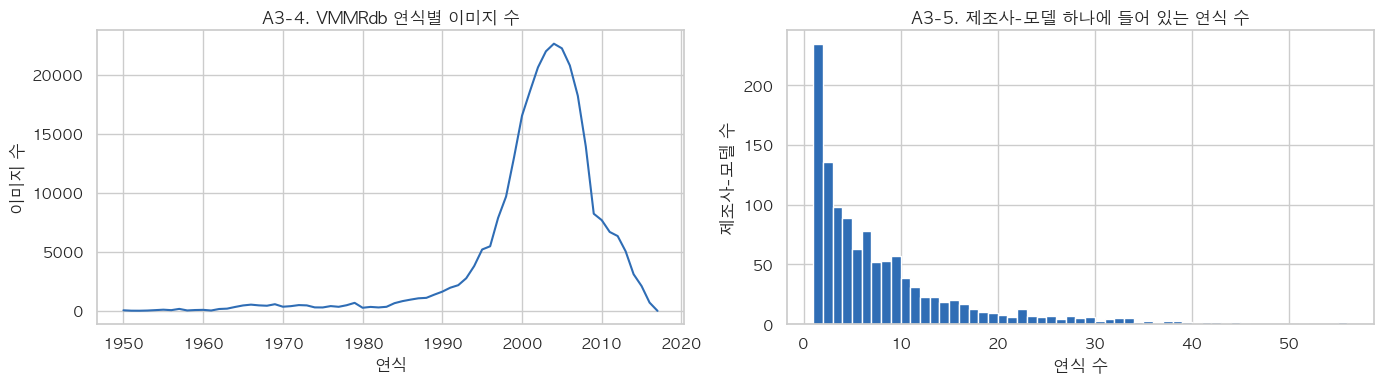

연식을 합치면 한 클래스에 평균 7.8개 연식(최대 55개)이 섞인다 → 세대 변경(풀체인지)으로 한 클래스 안에 외형이 다른 차가 섞일 수 있음 (클래스 내 변동성)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
vy = vm.dropna(subset=["year"])
vy[(vy.year >= 1950)].year.astype(int).value_counts().sort_index().plot(ax=axes[0], color=C_VM)
axes[0].set(title="A3-4. VMMRdb 연식별 이미지 수", xlabel="연식", ylabel="이미지 수")
years_per_model = vm.groupby("make_model")["year"].nunique()
axes[1].hist(years_per_model, bins=range(1, years_per_model.max() + 2), color=C_VM)
axes[1].set(title="A3-5. 제조사-모델 하나에 들어 있는 연식 수", xlabel="연식 수", ylabel="제조사-모델 수")
plt.tight_layout(); savefig("A3_3_years"); plt.show()
print(f"연식을 합치면 한 클래스에 평균 {years_per_model.mean():.1f}개 연식(최대 {years_per_model.max()}개)이 섞인다"
      " → 세대 변경(풀체인지)으로 한 클래스 안에 외형이 다른 차가 섞일 수 있음 (클래스 내 변동성)")

**A3 요약.**
- VMMRdb를 제조사-모델-연식 단위로 그대로 쓰면, 클래스 대부분이 20장 미만이라 학습이 어렵다.
- 그래서 **연식을 합친 제조사-모델** 단위가 현실적인 선택이다.
- 연식을 합쳐도 VMMRdb는 CompCars보다 불균형(Gini)이 훨씬 크다.
- CompCars는 모델당 이미지가 비교적 고르다. 그래서 "불균형"이라는 학습 난제가 덜 드러난다.

## A4. 계층 구조 분석 — "제조사"는 시각적으로 뭉친 그룹인가?

계층형 분류(제조사 → 차종)는 **1단계 그룹 안의 차들이 서로 닮았을 때** 유리하다. 하나의 제조사 안에 픽업트럭, 세단, SUV, 미니밴이 섞여 있다면 CNN에게 "제조사"는 겉모습으로 묶이지 않는 그룹이다.

CompCars의 **차체 유형(body type) 라벨**을 이용해 이것을 직접 측정한다.
- 이 분석이 **핵심 가설 H2**(Part C)의 데이터 근거다.

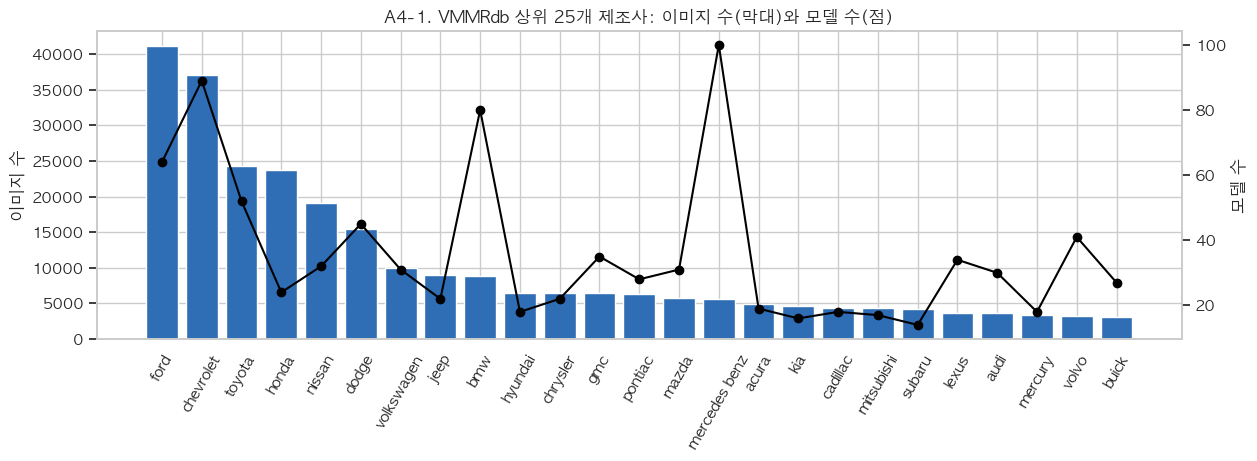

In [11]:
vm_make = vm.groupby("make").agg(이미지=("file", "size"), 모델=("model", "nunique")).sort_values("이미지", ascending=False)
fig, ax = plt.subplots(figsize=(14, 4))
top = vm_make.head(25)
ax.bar(top.index, top["이미지"], color=C_VM)
ax2 = ax.twinx(); ax2.plot(top.index, top["모델"], "o-", color="black", label="모델 수"); ax2.grid(False)
ax.set(title="A4-1. VMMRdb 상위 25개 제조사: 이미지 수(막대)와 모델 수(점)", ylabel="이미지 수"); ax2.set_ylabel("모델 수")
ax.tick_params(axis="x", rotation=60)
savefig("A4_1_vmmr_makes"); plt.show()

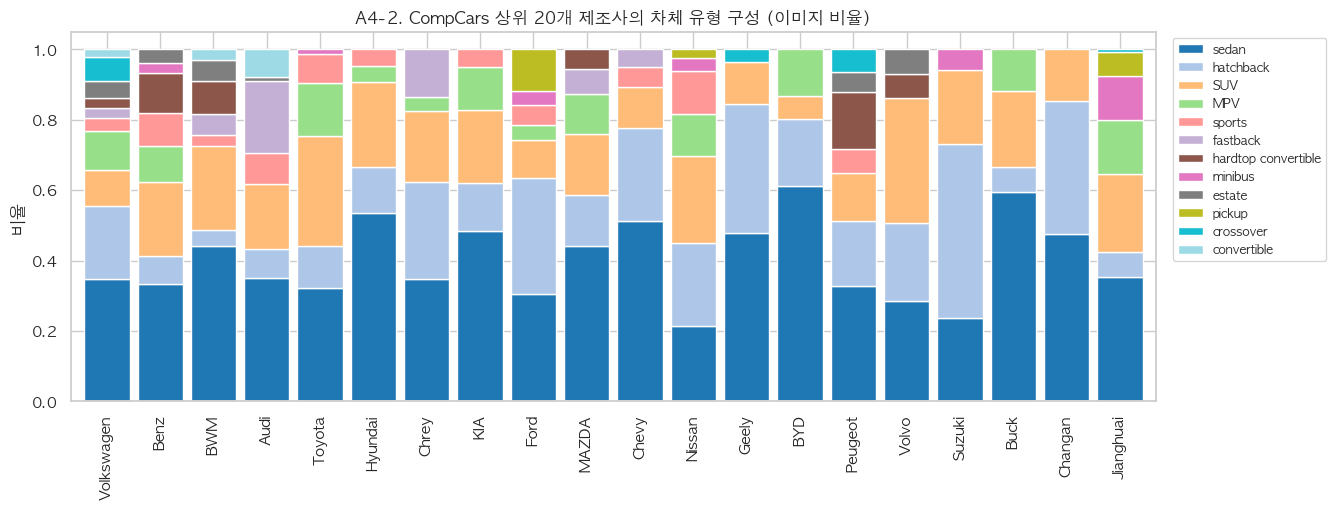

In [12]:
known = cc[cc.body_type != "unknown"]
cc_models = known.drop_duplicates("model_id")[["make", "model_id", "body_type"]]
top_makes = known.groupby("make").size().sort_values(ascending=False).head(20).index
mix = (known[known.make.isin(top_makes)].groupby(["make", "body_type"]).size()
       .unstack(fill_value=0).loc[top_makes])
mix = mix.div(mix.sum(axis=1), axis=0)
mix = mix[mix.sum().sort_values(ascending=False).index]
ax = mix.plot(kind="bar", stacked=True, figsize=(14, 4.8), colormap="tab20", width=0.85)
ax.set(title="A4-2. CompCars 상위 20개 제조사의 차체 유형 구성 (이미지 비율)", ylabel="비율", xlabel="")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
savefig("A4_2_make_bodytype_mix"); plt.show()

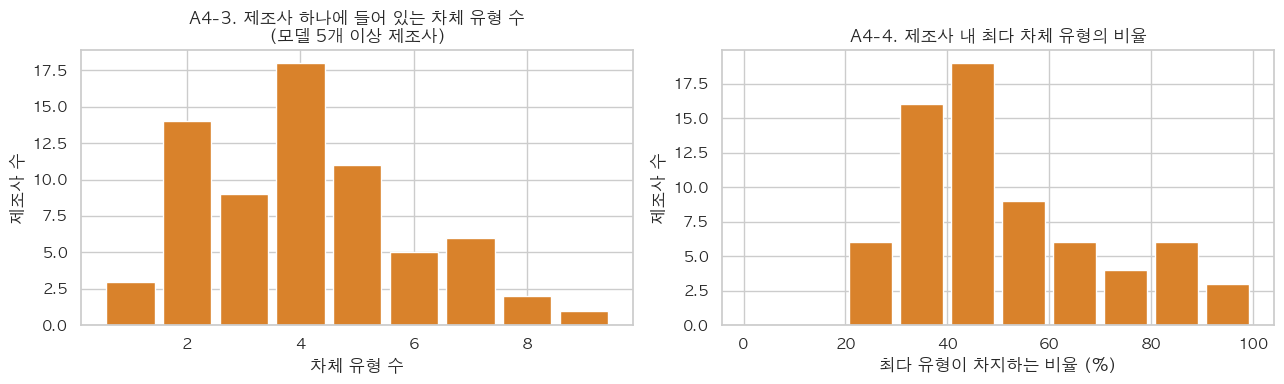

- 모델 5개 이상인 CompCars 제조사 **69개**는 평균 **4.1개** 차체 유형을 포함한다.
- 최다 유형이 절반도 안 되는 제조사: **59%**
- 가장 이질적인 제조사: Volkswagen, Nissan, Benz, Peugeot, Jianghuai / 가장 동질적인 제조사: LAND-ROVER, Jeep, Haval

,n_models,n_types,dominant_share,entropy
make,,,,
Volkswagen,41,10,0.32,0.81
Nissan,19,7,0.21,0.74
Benz,34,8,0.32,0.74
Peugeot,14,7,0.36,0.71
Jianghuai,15,7,0.33,0.71
Audi,30,7,0.33,0.71
Yiqi,16,7,0.25,0.70
Ford,20,7,0.30,0.69


In [13]:
def norm_entropy(counts):
    p = np.asarray(counts, float); p = p[p > 0] / p.sum()
    return float(-(p * np.log(p)).sum() / np.log(len(car_types))) if len(p) > 1 else 0.0

per_make = (cc_models.groupby("make").agg(n_models=("model_id", "size"),
                                         n_types=("body_type", "nunique"),
                                         dominant_share=("body_type", lambda s: s.value_counts(normalize=True).iloc[0]),
                                         entropy=("body_type", lambda s: norm_entropy(s.value_counts()))))
per_make = per_make[per_make.n_models >= 5].sort_values("entropy", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(per_make.n_types, bins=range(1, 11), color=C_CC, rwidth=0.85, align="left")
axes[0].set(title="A4-3. 제조사 하나에 들어 있는 차체 유형 수\n(모델 5개 이상 제조사)", xlabel="차체 유형 수", ylabel="제조사 수")
axes[1].hist(per_make.dominant_share * 100, bins=np.arange(0, 105, 10), color=C_CC, rwidth=0.85)
axes[1].set(title="A4-4. 제조사 내 최다 차체 유형의 비율", xlabel="최다 유형이 차지하는 비율 (%)", ylabel="제조사 수")
plt.tight_layout(); savefig("A4_3_make_heterogeneity"); plt.show()

display(Markdown(
    f"- 모델 5개 이상인 CompCars 제조사 **{len(per_make)}개**는 평균 **{per_make.n_types.mean():.1f}개** 차체 유형을 포함한다.\n"
    f"- 최다 유형이 절반도 안 되는 제조사: **{(per_make.dominant_share < 0.5).mean():.0%}**\n"
    f"- 가장 이질적인 제조사: {', '.join(per_make.head(5).index)} / 가장 동질적인 제조사: {', '.join(per_make.tail(3).index)}"))
per_make.head(8).round(2)

**A4 해석.** 대부분의 제조사는 여러 차체 유형을 동시에 만든다. 즉 **"제조사" 클래스 하나 안의 겉모습 차이가 크다.**

- 반대로 "픽업트럭" 그룹은 제조사가 달라도 실루엣이 비슷하다.
- 따라서 CNN 입장에서는 *제조사 → 차종* 계층보다 *차체 유형 → 차종* 계층이 1단계를 더 쉽게 만들 수 있다.
- 다만 제조사의 단서는 엠블럼·그릴처럼 **작은 영역**에 집중되어 있다. CNN이 이 단서를 배운다면 제조사 계층도 잘 작동할 수 있다. 이것이 Part C에서 H1과 H2를 맞붙이는 이유다.

## A5. 이미지 속성 — 해상도, 종횡비, 파일 크기, 손상 여부

모든 이미지를 여는 것은 오래 걸린다. 그래서 **데이터셋별 무작위 3,000장 샘플**로 측정한다(seed=42).

- 손상 검사는 `PIL.Image.verify()`를 쓴다.
- 흑백 여부는 64×64로 줄인 뒤 RGB 채널이 거의 같은지로 판정한다.

In [14]:
N_SAMPLE = 3000
def probe(path):
    rec = {"w": np.nan, "h": np.nan, "mode": None, "kb": os.path.getsize(path) / 1024, "corrupt": False, "gray": np.nan}
    try:
        with Image.open(path) as im:
            rec["w"], rec["h"], rec["mode"] = *im.size, im.mode
            im.verify()
        with Image.open(path) as im:
            a = np.asarray(im.convert("RGB").resize((64, 64)), dtype=float)
            rec["gray"] = bool(np.abs(a[..., 0] - a[..., 1]).mean() < 2 and np.abs(a[..., 1] - a[..., 2]).mean() < 2)
    except Exception:
        rec["corrupt"] = True
    return rec

def build_probe():
    vs = vm.sample(N_SAMPLE, random_state=SEED)
    cs = cc.sample(N_SAMPLE, random_state=SEED)
    a = [dict(dataset="VMMRdb", key=f"{r.folder}/{r.file}", **probe(VMMR / r.folder / r.file)) for r in vs.itertuples()]
    b = [dict(dataset="CompCars", key=r.rel, **probe(COMP / "image" / r.rel)) for r in cs.itertuples()]
    return pd.DataFrame(a + b)

prb = cached("image_probe_sample", build_probe)
prb["short"] = prb[["w", "h"]].min(axis=1); prb["aspect"] = prb.w / prb.h
summary = prb.groupby("dataset").agg(
    샘플=("key", "size"), 손상=("corrupt", "sum"), 흑백비율=("gray", "mean"),
    폭_중앙=("w", "median"), 높이_중앙=("h", "median"), 짧은변_최소=("short", "min"), 짧은변_중앙=("short", "median"),
    짧은변_최대=("short", "max"), 종횡비_중앙=("aspect", "median"), 파일KB_중앙=("kb", "median"))
summary.round(2)

,샘플,손상,흑백비율,폭_중앙,높이_중앙,짧은변_최소,짧은변_중앙,짧은변_최대,종횡비_중앙,파일KB_중앙
dataset,,,,,,,,,,
CompCars,3000,0,0.02,800.0,567.0,327,567.0,800,1.45,85.37
VMMRdb,3000,0,0.01,588.0,408.0,159,380.0,560,1.34,40.99


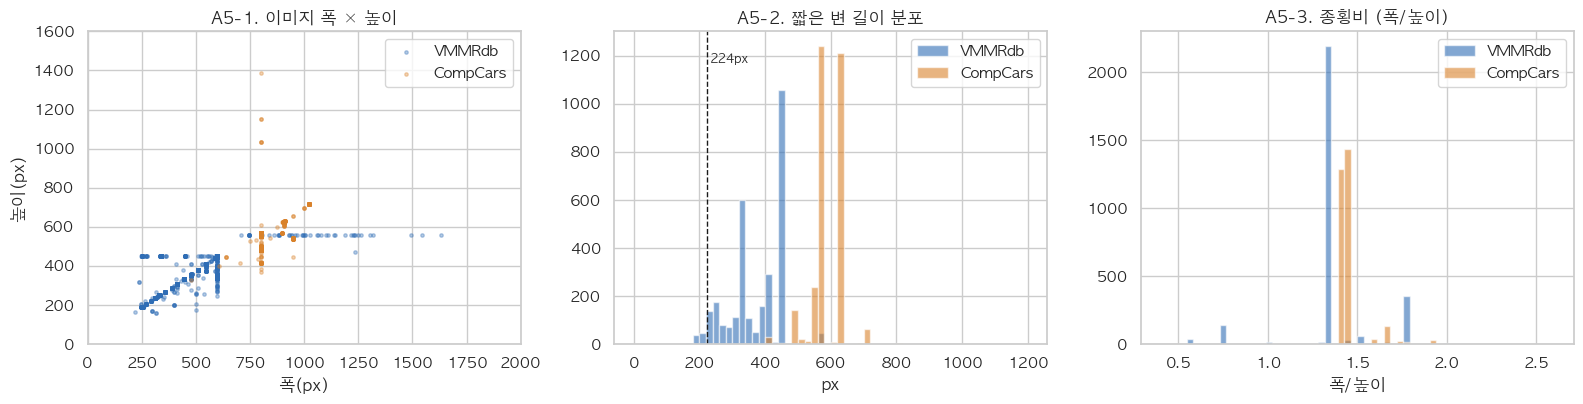

VMMRdb 해상도 상위 빈도:
w    h  
600  450    824
     337    318
548  408    245
588  440    142
337  450    125
dtype: int64


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ds, col in [("VMMRdb", C_VM), ("CompCars", C_CC)]:
    d = prb[(prb.dataset == ds) & ~prb.corrupt]
    axes[0].scatter(d.w, d.h, s=6, alpha=0.35, color=col, label=ds)
    axes[1].hist(d.short, bins=60, alpha=0.6, color=col, label=ds, range=(0, 1200))
    axes[2].hist(d.aspect, bins=60, alpha=0.6, color=col, label=ds, range=(0.4, 2.6))
axes[0].set(title="A5-1. 이미지 폭 × 높이", xlabel="폭(px)", ylabel="높이(px)", xlim=(0, 2000), ylim=(0, 1600))
axes[1].axvline(224, color="k", ls="--", lw=1); axes[1].text(230, axes[1].get_ylim()[1] * 0.9, "224px", fontsize=9)
axes[1].set(title="A5-2. 짧은 변 길이 분포", xlabel="px")
axes[2].set(title="A5-3. 종횡비 (폭/높이)", xlabel="폭/높이")
for a in axes: a.legend()
plt.tight_layout(); savefig("A5_image_properties"); plt.show()
print("VMMRdb 해상도 상위 빈도:"); print(prb[prb.dataset == "VMMRdb"].groupby(["w", "h"]).size().sort_values(ascending=False).head(5))

**A5 해석.**
- VMMRdb는 Craigslist 업로드 규격 때문에 해상도가 몇 가지로 몰려 있다(파일명의 `600x450` 등).
- CompCars는 웹 이미지라 해상도가 다양하고 더 크다.
- 두 데이터셋 모두 짧은 변이 CNN 입력(224px 내외)보다 충분히 크다. 따라서 **해상도 자체는 병목이 아니다.**
- 다만 엠블럼처럼 작은 단서는 리사이즈하면 몇 픽셀로 줄어든다. 입력 크기를 바꾸는 실험은 의미가 있다.

## A6. CompCars 전용 라벨 — 시점, 차가 차지하는 면적, 차체 유형, 공식 분할, 부품

VMMRdb에는 없지만 CompCars에만 있는 라벨들이다. **보조 데이터로서 CompCars의 가치**는 대부분 여기서 나온다.

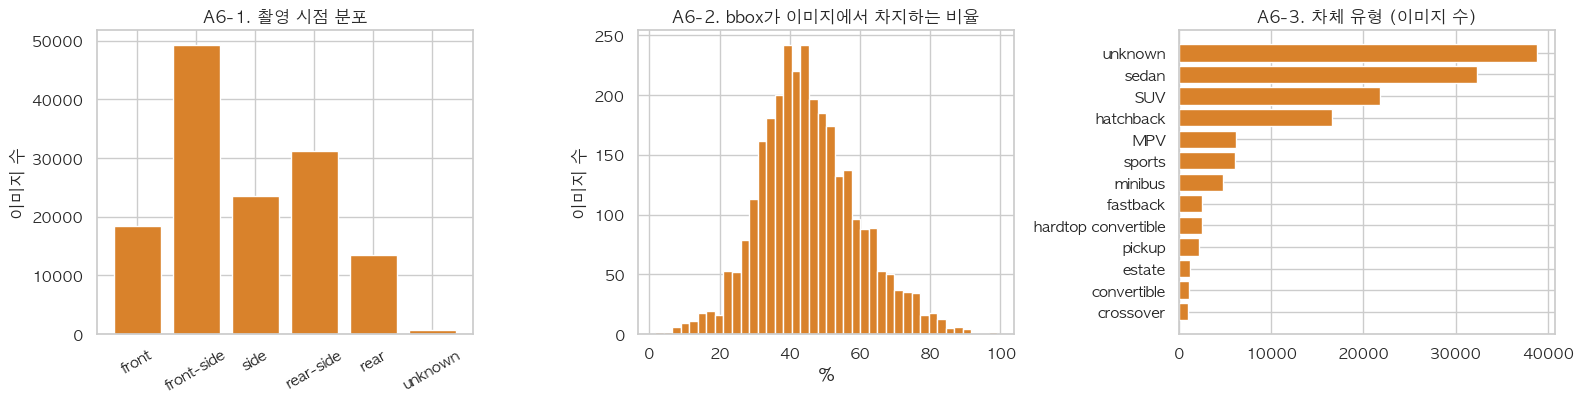

bbox 점유율 중앙값: 44% → 차가 대부분 화면을 채운, 정돈된 웹 사진


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
order = ["front", "front-side", "side", "rear-side", "rear", "unknown"]
vc = cc.view.value_counts().reindex(order).fillna(0)
axes[0].bar(vc.index, vc.values, color=C_CC); axes[0].set(title="A6-1. 촬영 시점 분포", ylabel="이미지 수")
axes[0].tick_params(axis="x", rotation=30)

ccp = prb[(prb.dataset == "CompCars") & ~prb.corrupt].merge(cc[["rel", "x1", "y1", "x2", "y2"]], left_on="key", right_on="rel")
ccp["area"] = ((ccp.x2 - ccp.x1) * (ccp.y2 - ccp.y1) / (ccp.w * ccp.h)).clip(0, 1)
axes[1].hist(ccp.area.dropna() * 100, bins=40, color=C_CC)
axes[1].set(title="A6-2. bbox가 이미지에서 차지하는 비율", xlabel="%", ylabel="이미지 수")

bt = cc.body_type.value_counts()
axes[2].barh(bt.index[::-1], bt.values[::-1], color=C_CC); axes[2].set(title="A6-3. 차체 유형 (이미지 수)")
plt.tight_layout(); savefig("A6_compcars_labels"); plt.show()
print(f"bbox 점유율 중앙값: {ccp.area.median():.0%} → 차가 대부분 화면을 채운, 정돈된 웹 사진")

In [17]:
split = {}
for s in ["train", "test"]:
    lines = [l.strip() for l in open(COMP / f"train_test_split/classification/{s}.txt") if l.strip()]
    ids = pd.Series([int(l.split("/")[1]) for l in lines])
    split[s] = {"이미지": len(lines), "모델": ids.nunique(), "모델당 중앙값": ids.value_counts().median(),
                "모델당 최소": ids.value_counts().min(), "모델당 최대": ids.value_counts().max()}
split_df = pd.DataFrame(split).T
part_counts = collections.Counter()
for p in (COMP / "part").rglob("*.jpg"):
    part_counts[int(p.parent.name)] += 1
PART = {1: "headlight", 2: "taillight", 3: "fog light", 4: "air intake", 5: "console", 6: "steering wheel", 7: "dashboard", 8: "gear lever"}
display(Markdown("**공식 분류 분할 (classification)**")); display(split_df)
display(Markdown(f"**부품 이미지**: 총 {sum(part_counts.values()):,}장"))
pd.Series({PART[k]: v for k, v in sorted(part_counts.items())}, name="이미지 수").to_frame().T

**공식 분류 분할 (classification)**

,이미지,모델,모델당 중앙값,모델당 최소,모델당 최대
train,16016.0,431.0,31.0,10.0,143.0
test,14939.0,431.0,29.0,8.0,140.0


**부품 이미지**: 총 27,618장

,headlight,taillight,fog light,air intake,console,steering wheel,dashboard,gear lever
이미지 수,3705,3563,3177,3407,3350,3503,3478,3435


**A6 해석.**
- CompCars는 시점과 bbox가 라벨링되어 있다. 그래서 **"시점별로 계층의 이득이 다른가?"** 같은 분석을 할 수 있다.
- 공식 분류 분할은 전체 1,716개 모델 중 431개만 쓴다. 클래스당 이미지도 고르다.
- 즉 CompCars는 **잘 정돈된 벤치마크**에 가깝다. VMMRdb의 거친 실제 분포와 대비된다.

## A7. 시각 검사 — 숫자로는 안 보이는 것들

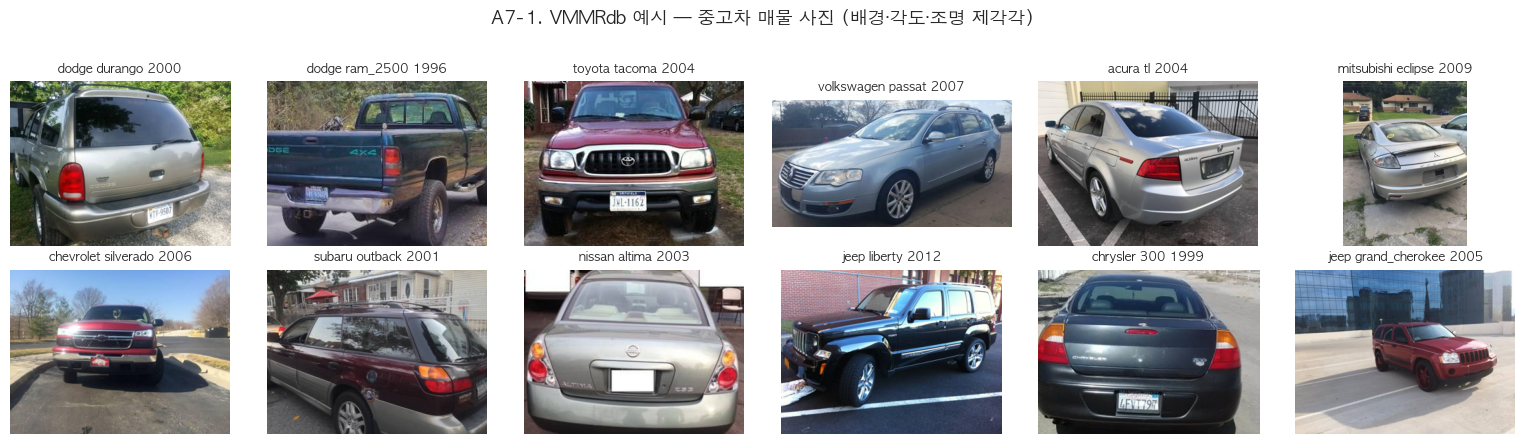

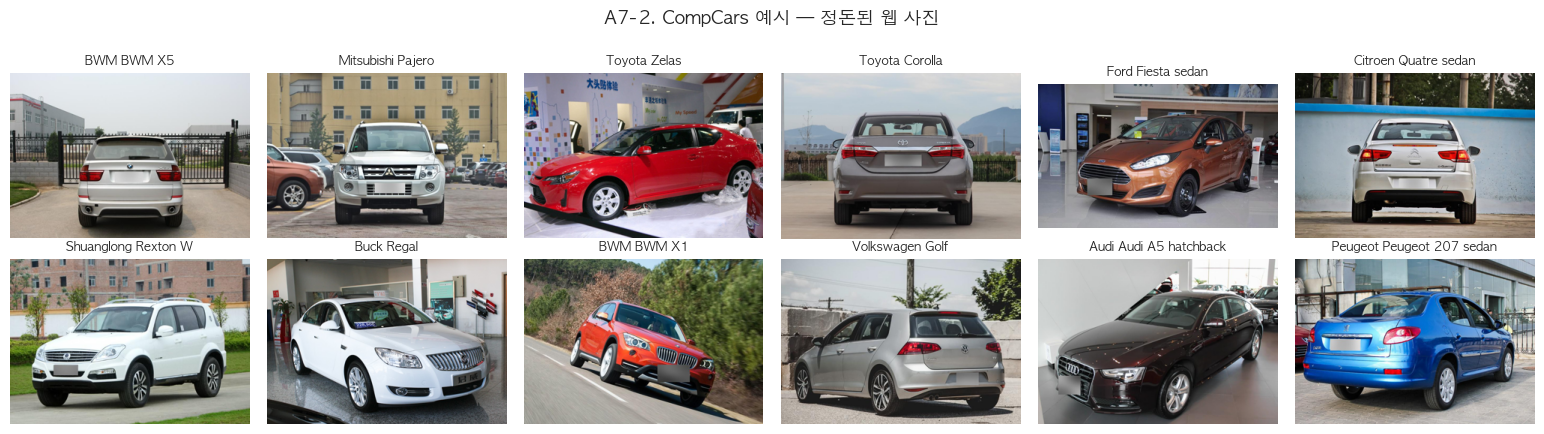

In [18]:
def show_grid(items, ncols=6, title=None, name=None, size=2.6):
    """items: [(path, caption), ...]"""
    nrows = math.ceil(len(items) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * size, nrows * size * 0.85))
    for ax in np.atleast_1d(axes).ravel():
        ax.axis("off")
    for ax, (p, cap) in zip(np.atleast_1d(axes).ravel(), items):
        with Image.open(p) as im:
            im = im.convert("RGB"); im.thumbnail((320, 320))
            ax.imshow(im)
        ax.set_title(cap, fontsize=9)
    if title: fig.suptitle(title, fontsize=13, fontweight="bold", y=1.0)
    plt.tight_layout()
    if name: savefig(name)
    plt.show()

def vm_items(make_model, k, seed=SEED, caption=None):
    d = vm[vm.make_model == make_model].sample(k, random_state=seed)
    return [(VMMR / r.folder / r.file, caption or f"{r.make} {r.model} {int(r.year) if r.year == r.year else ''}") for r in d.itertuples()]

rng = np.random.default_rng(SEED)
big_vm = vm.groupby("make_model").size().sort_values(ascending=False).head(60).index
show_grid(sum([vm_items(m, 1, seed=i) for i, m in enumerate(rng.choice(big_vm, 12, replace=False))], []),
          title="A7-1. VMMRdb 예시 — 중고차 매물 사진 (배경·각도·조명 제각각)", name="A7_1_vmmr_examples")

big_cc = cc.groupby("model_id").size().sort_values(ascending=False).head(80).index
cc_ex = [cc[cc.model_id == m].sample(1, random_state=SEED).iloc[0] for m in rng.choice(big_cc, 12, replace=False)]
show_grid([(COMP / "image" / r.rel, f"{r.make} {r.model}"[:28]) for r in cc_ex],
          title="A7-2. CompCars 예시 — 정돈된 웹 사진", name="A7_2_compcars_examples")

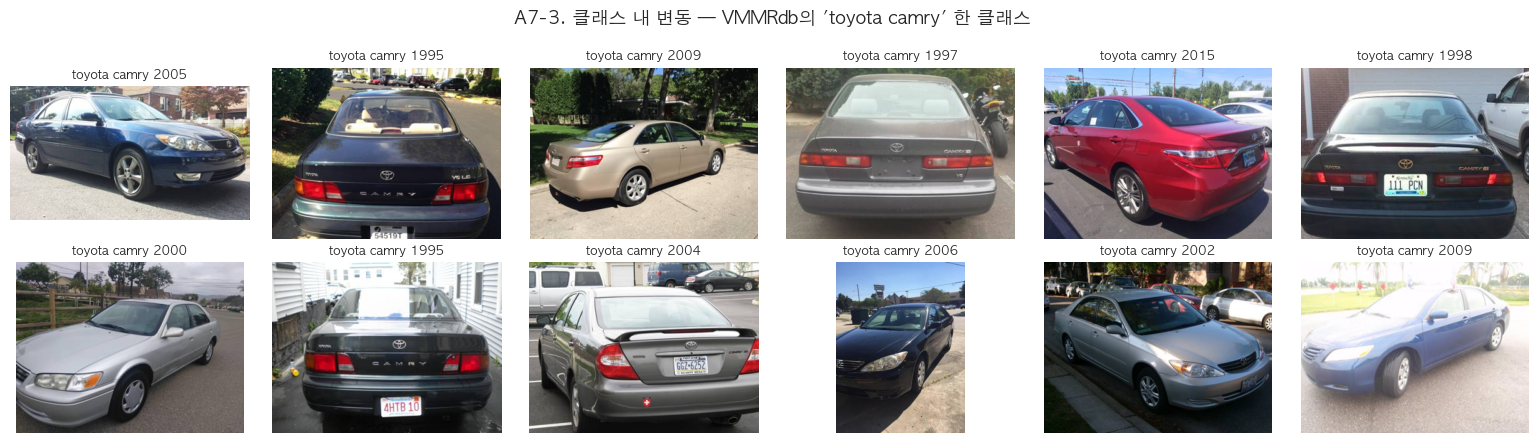

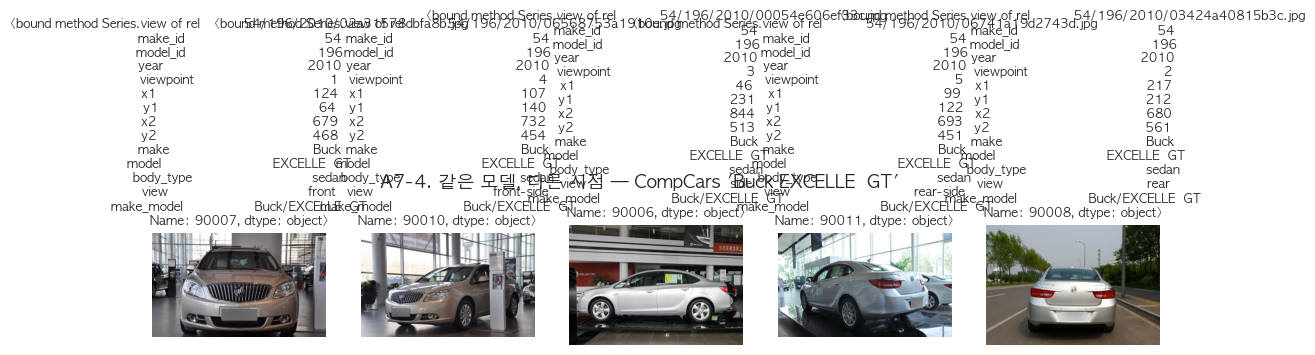

In [19]:
show_grid(vm_items("toyota/camry", 12), title="A7-3. 클래스 내 변동 — VMMRdb의 'toyota camry' 한 클래스",
          name="A7_3_intra_class")

m5 = cc[cc.viewpoint > 0].groupby("model_id").view.nunique()
mid = cc[cc.model_id.isin(m5[m5 == 5].index)].groupby("model_id").size().idxmax()
rows = [cc[(cc.model_id == mid) & (cc.view == v)].iloc[0] for v in ["front", "front-side", "side", "rear-side", "rear"]]
show_grid([(COMP / "image" / r.rel, r.view) for r in rows], ncols=5,
          title=f"A7-4. 같은 모델, 다른 시점 — CompCars '{rows[0].make} {rows[0].model}'", name="A7_4_viewpoints")

### 형제차와 미세 차이 — 세밀한 분류의 진짜 어려움
- **형제차(badge engineering)**: Chevrolet Silverado ↔ GMC Sierra, Chevrolet Tahoe ↔ GMC Yukon은 **같은 차체에 엠블럼과 그릴만 다른 차**다.
- **같은 차의 트림 차이**: BMW 325i ↔ 328i는 같은 3시리즈의 엔진 트림 차이다.

이런 쌍은 이미지 전체 모양으로는 구분하기 거의 불가능하다.

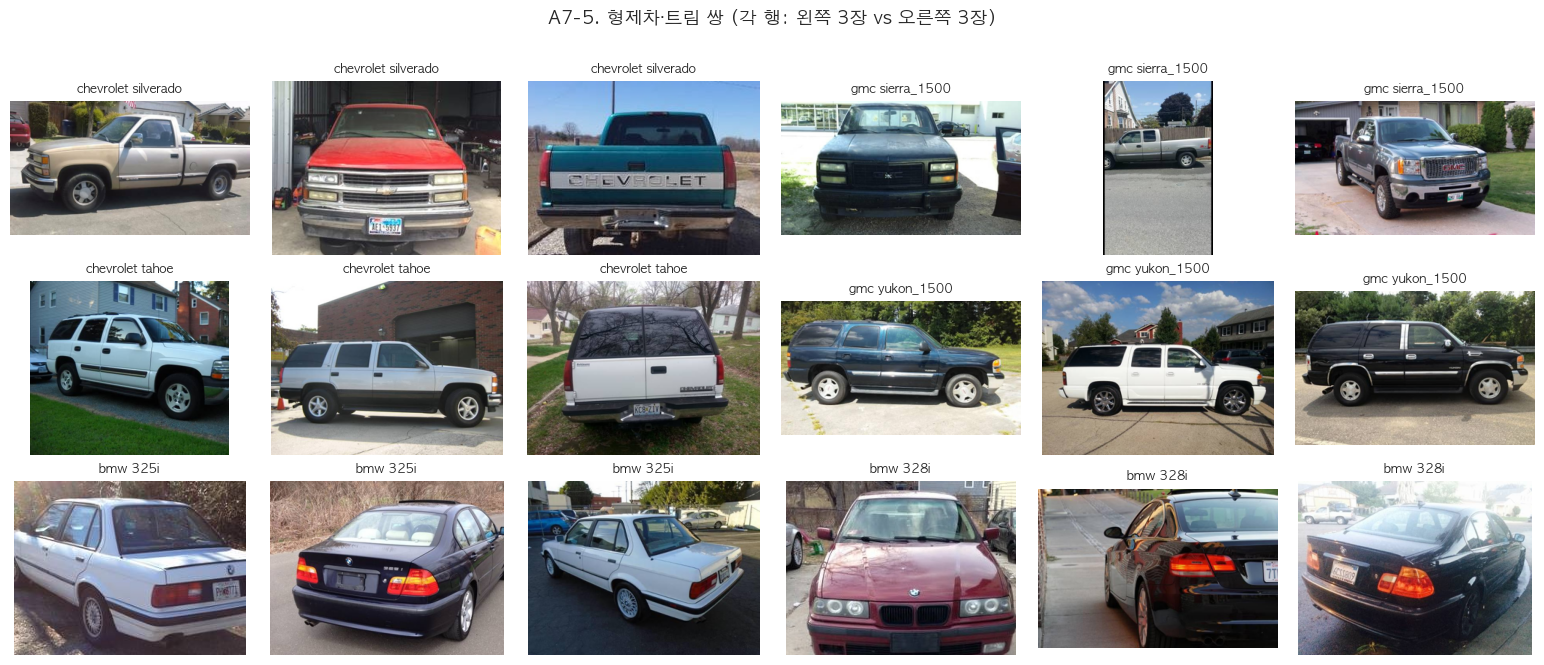

In [20]:
pairs = [("chevrolet/silverado", "gmc/sierra_1500"), ("chevrolet/tahoe", "gmc/yukon_1500"), ("bmw/325i", "bmw/328i")]
items = []
for a, b in pairs:
    items += vm_items(a, 3, caption=a.replace("/", " ")) + vm_items(b, 3, caption=b.replace("/", " "))
show_grid(items, ncols=6, title="A7-5. 형제차·트림 쌍 (각 행: 왼쪽 3장 vs 오른쪽 3장)", name="A7_5_twins")

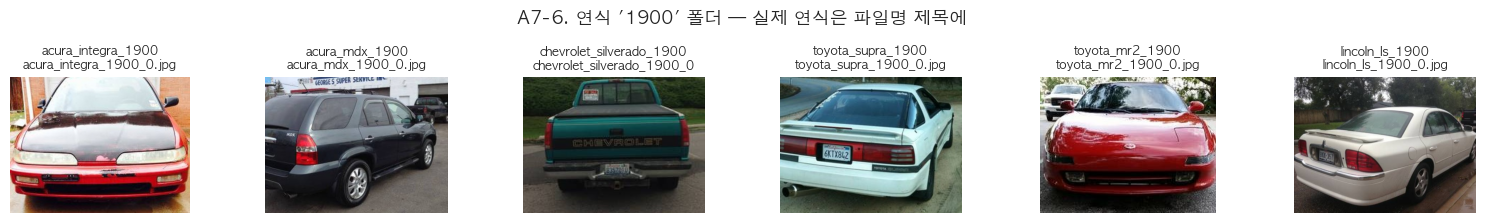

In [21]:
noise = vm[vm.year == 1900].sample(min(6, (vm.year == 1900).sum()), random_state=SEED)
show_grid([(VMMR / r.folder / r.file, f"{r.folder}\n{(title_of(r.file) or r.file)[:26]}") for r in noise.itertuples()], ncols=6,
          title="A7-6. 연식 '1900' 폴더 — 실제 연식은 파일명 제목에", name="A7_6_label_noise")

## A8. 공통 제조사 매핑

계층형 전이(CompCars로 제조사 사전학습 → VMMRdb)를 하려면 두 데이터셋의 제조사 이름이 맞아야 한다.

그런데 CompCars 제조사명에는 **오타와 중복**이 있다(`BWM`, `Buck`, `Lamorghini`, `Chevy`, `Benz`, `Lotus`·`Saab` 중복 등). 그래서 이름을 정규화하고 별칭을 직접 매핑한다.

In [22]:
CC_ALIAS = {"bwm": "bmw", "buck": "buick", "benz": "mercedesbenz", "chevy": "chevrolet",
            "lamorghini": "lamborghini", "mustang": "ford"}
cc["make_key"] = cc.make.map(lambda s: CC_ALIAS.get(norm(s), norm(s)))
vm["make_key"] = vm.make.map(norm)
dup_names = pd.Series(cc_make_names).map(norm).value_counts()
print("CompCars에서 같은 이름이 두 번 나오는 제조사:", dup_names[dup_names > 1].index.tolist())

common = (vm.groupby("make_key").size().rename("VMMRdb 이미지").to_frame()
          .join(cc.groupby("make_key").size().rename("CompCars 이미지"), how="inner")
          .join(vm.groupby("make_key").make_model.nunique().rename("VMMRdb 모델"))
          .join(cc.groupby("make_key").model_id.nunique().rename("CompCars 모델"))
          .sort_values("VMMRdb 이미지", ascending=False))
common.to_csv(OUT / "common_makes.csv")
cover = common["VMMRdb 이미지"].sum() / len(vm)
print(f"공통 제조사 {len(common)}개 (VMMRdb {vm.make_key.nunique()}개 중) → VMMRdb 이미지의 {cover:.1%}를 덮는다")
common.head(15)

CompCars에서 같은 이름이 두 번 나오는 제조사: ['saab', 'lotus']
공통 제조사 50개 (VMMRdb 75개 중) → VMMRdb 이미지의 94.6%를 덮는다


,VMMRdb 이미지,CompCars 이미지,VMMRdb 모델,CompCars 모델
make_key,,,,
ford,41203,4286,64,57
chevrolet,37001,3688,89,40
toyota,24354,4908,52,58
honda,23681,2492,24,36
nissan,19125,3831,32,48
dodge,15501,1449,45,16
volkswagen,9959,5720,31,67
jeep,8987,954,22,9
bmw,8848,4531,80,50


## A9. 비교 스코어카드와 데이터셋 선택

In [23]:
vs_mm = stats.loc["VMMRdb · 제조사-모델"]; cs_m = stats.loc["CompCars · 모델"]
card = pd.DataFrame({
    "VMMRdb": ["Tafazzoli et al., CVPRW 2017 · github.com/faezetta/VMMRdb", "제조사·모델·연식 분류",
               f"{len(vm):,}", f"{len(vm_folders):,} (연식 포함) / {int(vs_mm['클래스 수']):,} (연식 합침)",
               f"{vm.make.nunique()}", f"중앙값 {vs_mm['중앙값']:.0f} · 최대 {int(vs_mm['최대']):,} · Gini {vs_mm['Gini']}",
               f"짧은 변 중앙 {summary.loc['VMMRdb', '짧은변_중앙']:.0f}px", "없음", "없음 (파일명 제목만)",
               f"연식 1900 폴더 {len(placeholder)}개, 단위 불일치 {len(variants)}쌍",
               "실제 사용자 사진과 비슷한 분포, 극심한 롱테일", "공식 분할 없음, 라벨 노이즈"],
    "CompCars": ["Yang et al., CVPR 2015 · mmlab.ie.cuhk.edu.hk/datasets/comp_cars", "제조사·모델 분류, 검증, 속성 예측",
                 f"{len(cc):,}", f"{int(cs_m['클래스 수']):,} 모델",
                 f"{cc.make_id.nunique()}", f"중앙값 {cs_m['중앙값']:.0f} · 최대 {int(cs_m['최대']):,} · Gini {cs_m['Gini']}",
                 f"짧은 변 중앙 {summary.loc['CompCars', '짧은변_중앙']:.0f}px", f"있음 (431 모델, {split['train']['이미지']:,}/{split['test']['이미지']:,})",
                 "시점·bbox·차체 유형·부품", "제조사명 오타·중복",
                 "구조화된 보조 라벨, 비교적 균형", "중국 시장 브랜드 다수, 정돈된 웹 사진이라 난제가 약함"],
}, index=["출처", "분류 과제", "이미지 수", "클래스 수", "제조사 수", "클래스 분포 (제조사-모델)",
          "해상도", "공식 분할", "추가 라벨", "라벨 품질 이슈", "장점", "어려움"])
card.to_csv(OUT / "comparison_table.csv")
card

,VMMRdb,CompCars
출처,"Tafazzoli et al., CVPRW 2017 · github.com/faez...","Yang et al., CVPR 2015 · mmlab.ie.cuhk.edu.hk/..."
분류 과제,제조사·모델·연식 분류,"제조사·모델 분류, 검증, 속성 예측"
이미지 수,"285,086","136,726"
클래스 수,"9,170 (연식 포함) / 1,175 (연식 합침)","1,716 모델"
제조사 수,75,163
클래스 분포 (제조사-모델),"중앙값 33 · 최대 6,895 · Gini 0.804",중앙값 95 · 최대 303 · Gini 0.331
해상도,짧은 변 중앙 380px,짧은 변 중앙 567px
공식 분할,없음,"있음 (431 모델, 16,016/14,939)"
추가 라벨,없음 (파일명 제목만),시점·bbox·차체 유형·부품
라벨 품질 이슈,"연식 1900 폴더 14개, 단위 불일치 79쌍",제조사명 오타·중복


In [24]:
display(Markdown(f"""
### 선택: **주 데이터셋 VMMRdb + 보조 데이터셋 CompCars**

1. **과제 취지(도전적인 데이터)에 맞는다.**
   - VMMRdb는 제조사-모델 단위에서도 클래스가 {int(vs_mm['클래스 수']):,}개이고, 클래스 크기 중앙값은 {vs_mm['중앙값']:.0f}장이다.
   - 최대 클래스는 {int(vs_mm['최대']):,}장이고, Gini는 {vs_mm['Gini']}다. CompCars의 {cs_m['Gini']}보다 훨씬 불균형하다.
   - **많은 클래스·불균형·세밀한 분류·라벨 노이즈**를 실제 수치로 보일 수 있다.
2. **현실적인 분포다.** 배경과 각도가 제각각인 매물 사진은 시연 대상(일반 사용자가 찍은 사진)과 비슷하다.
3. **CompCars는 보조로 쓴다.**
   - 시점·차체 유형 라벨이 있어서 핵심 가설(H2)의 근거와 분석 도구가 된다.
   - 공통 제조사 {len(common)}개로 제조사 사전학습도 가능하다.
   - 반면 정돈된 사진과 고른 분포 때문에, 단독으로는 난제가 약하다.
"""))


### 선택: **주 데이터셋 VMMRdb + 보조 데이터셋 CompCars**

1. **과제 취지(도전적인 데이터)에 맞는다.**
   - VMMRdb는 제조사-모델 단위에서도 클래스가 1,175개이고, 클래스 크기 중앙값은 33장이다.
   - 최대 클래스는 6,895장이고, Gini는 0.804다. CompCars의 0.331보다 훨씬 불균형하다.
   - **많은 클래스·불균형·세밀한 분류·라벨 노이즈**를 실제 수치로 보일 수 있다.
2. **현실적인 분포다.** 배경과 각도가 제각각인 매물 사진은 시연 대상(일반 사용자가 찍은 사진)과 비슷하다.
3. **CompCars는 보조로 쓴다.**
   - 시점·차체 유형 라벨이 있어서 핵심 가설(H2)의 근거와 분석 도구가 된다.
   - 공통 제조사 50개로 제조사 사전학습도 가능하다.
   - 반면 정돈된 사진과 고른 분포 때문에, 단독으로는 난제가 약하다.


# Part B. 실험 범위 확정 — 50개 클래스

전체 1,000개 이상의 클래스는 수업 컴퓨팅 자원으로 다루기 어렵다. 그래서 **테스트 데이터를 보기 전에** 아래 규칙으로 범위를 확정한다.

1. 연식을 제거하고 `제조사-모델`로 합친다.
2. 두 데이터셋의 **공통 제조사**만 남긴다. (A8)
3. **단위 불일치 변형 클래스**(`civic_coupe` 등)는 제외한다. (A2)
4. 이미지 `MIN_IMG`장 이상인 모델을 5개 이상 가진 제조사를 고른다.
5. 총 이미지가 많은 순으로 상위 9개 제조사를 고르고, 10번째로 **GMC를 "형제차 탐침"으로 포함**한다.
   - GMC는 Chevrolet의 형제 브랜드다(Silverado↔Sierra, Tahoe↔Yukon).
   - 그래서 "제조사 계층이 실패하는 지점"을 일부러 실험에 넣는다.
6. 각 제조사에서 이미지가 많은 모델 5개를 골라 **10 × 5 = 50개 클래스**를 만든다.
7. 클래스 크기는 맞추지 않는다. 원래 불균형을 그대로 유지한다.

In [25]:
COMMON_KEYS = set(common.index)
TWIN_MAKE, N_MAKES, N_MODELS = "gmc", 10, 5
mmc = vm.groupby(["make", "make_key", "model"]).size().rename("n").reset_index()
mmc["variant"] = [(m, mo) in VARIANT_SET for m, mo in zip(mmc.make, mmc.model)]

log = []
for MIN_IMG in [100, 80, 50]:                       # 조건 미달 시 단계적으로 완화
    elig = mmc[mmc.make_key.isin(COMMON_KEYS) & ~mmc.variant & (mmc.n >= MIN_IMG)]
    rank = (elig.groupby("make").agg(models=("model", "size"), images=("n", "sum"))
                .query("models >= @N_MODELS").sort_values("images", ascending=False))
    log.append(f"MIN_IMG={MIN_IMG}: 조건 충족 제조사 {len(rank)}개")
    if len(rank) >= N_MAKES:
        break
makes = [m for m in rank.index if m != TWIN_MAKE][: N_MAKES - 1]
makes += [TWIN_MAKE] if TWIN_MAKE in rank.index else [m for m in rank.index if m not in makes][:1]
sel = (elig[elig.make.isin(makes)].sort_values("n", ascending=False).groupby("make").head(N_MODELS)
       .assign(make=lambda d: pd.Categorical(d.make, makes, ordered=True)).sort_values(["make", "n"], ascending=[True, False]))
print(*log, sep="\n")
display(rank.assign(selected=rank.index.isin(makes)).head(14))

MIN_IMG=100: 조건 충족 제조사 25개


,models,images,selected
make,,,
ford,27,39381,True
chevrolet,35,35640,True
toyota,23,22985,True
honda,12,21144,True
nissan,15,18709,True
dodge,17,15018,True
volkswagen,11,8923,True
jeep,9,8436,True
bmw,22,7630,True


In [26]:
BODY = {  # 50개 클래스의 차체 유형 (수동 매핑, 시각 계층 실험용)
    "ford": {"mustang": "sports", "f150": "pickup", "explorer": "SUV", "taurus": "sedan", "focus": "sedan"},
    "chevrolet": {"silverado": "pickup", "impala": "sedan", "corvette": "sports", "tahoe": "SUV", "malibu": "sedan"},
    "toyota": {"camry": "sedan", "corolla": "sedan", "4runner": "SUV", "sienna": "minivan", "tacoma": "pickup", "prius": "hatchback"},
    "honda": {"civic": "sedan", "accord": "sedan", "odyssey": "minivan", "cr-v": "SUV", "pilot": "SUV"},
    "nissan": {"altima": "sedan", "maxima": "sedan", "sentra": "sedan", "pathfinder": "SUV", "quest": "minivan", "murano": "SUV"},
    "dodge": {"grand caravan": "minivan", "durango": "SUV", "ram_1500": "pickup", "ram_2500": "pickup", "charger": "sedan", "neon": "sedan"},
    "volkswagen": {"jetta": "sedan", "passat": "sedan", "beetle": "hatchback", "gti": "hatchback", "golf": "hatchback"},
    "jeep": {"grand_cherokee": "SUV", "liberty": "SUV", "wrangler": "SUV", "cherokee": "SUV", "patriot": "SUV", "compass": "SUV"},
    "bmw": {"325i": "sedan", "x5": "SUV", "328i": "sedan", "528i": "sedan", "530i": "sedan", "m3": "sports"},
    "hyundai": {"sonata": "sedan", "elantra": "sedan", "accent": "sedan", "santafe": "SUV", "tiburon": "sports"},
    "chrysler": {"town&country": "minivan", "sebring": "sedan", "300": "sedan", "pacifica": "minivan", "pt cruiser": "hatchback"},
    "gmc": {"sierra_1500": "pickup", "yukon_1500": "SUV", "envoy": "SUV", "jimmy": "SUV", "acadia": "SUV", "sonoma": "pickup"},
}
sel["body_type"] = [BODY.get(m, {}).get(mo, "unknown") for m, mo in zip(sel.make.astype(str), sel.model)]
sel["years"] = [vm[(vm.make == m) & (vm.model == mo)].year.nunique() for m, mo in zip(sel.make.astype(str), sel.model)]
assert (sel.body_type != "unknown").all(), f"차체 유형 매핑 누락: {sel[sel.body_type == 'unknown'][['make', 'model']].values}"
sel = sel.drop(columns=["variant"]).rename(columns={"n": "n_images"}).reset_index(drop=True)
sel.to_csv(OUT / "selected_50_classes.csv", index=False)
print(f"선정 클래스 {len(sel)}개 · 제조사 {sel.make.nunique()}개 · 이미지 {sel.n_images.sum():,}장")
sel

선정 클래스 50개 · 제조사 10개 · 이미지 119,032장


,make,make_key,model,n_images,body_type,years
0,ford,ford,mustang,5775,sports,51
1,ford,ford,f150,5018,pickup,43
2,ford,ford,explorer,4913,SUV,27
3,ford,ford,taurus,3323,sedan,28
4,ford,ford,focus,3070,sedan,17
5,chevrolet,chevrolet,silverado,5294,pickup,44
6,chevrolet,chevrolet,impala,3941,sedan,42
7,chevrolet,chevrolet,corvette,2973,sports,55
8,chevrolet,chevrolet,tahoe,2601,SUV,24
9,chevrolet,chevrolet,malibu,2178,sedan,39


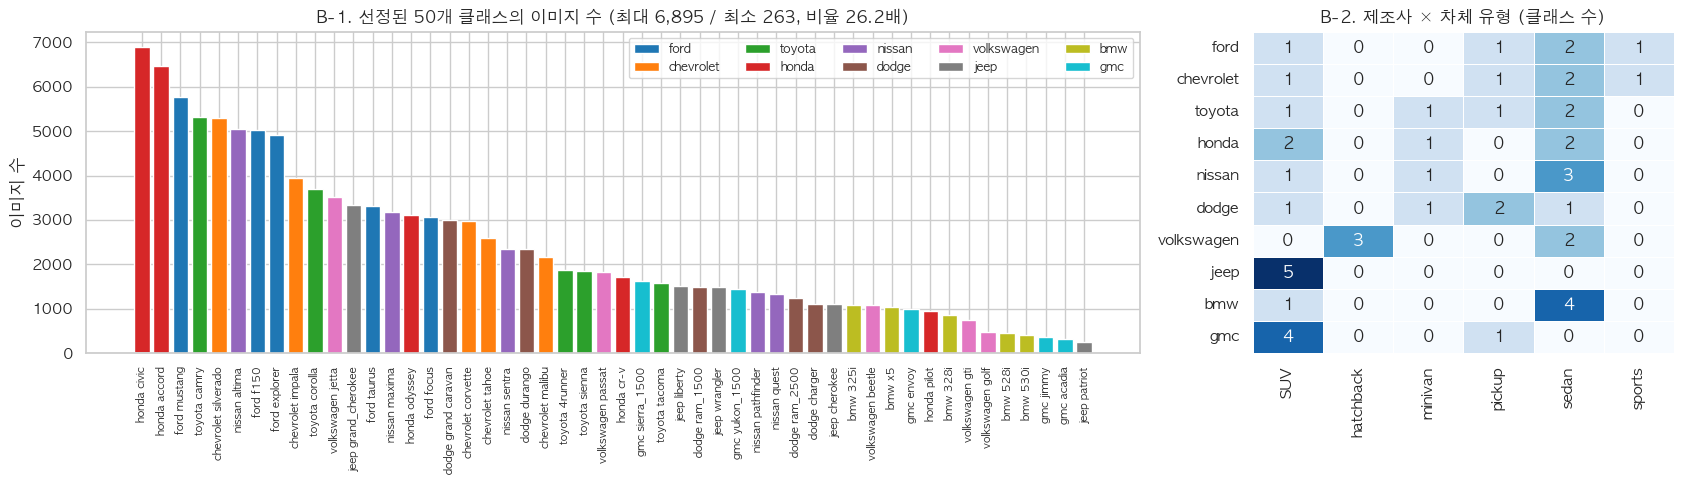

**1단계 그룹 후보 비교** — 제조사 그룹 10개 vs 차체 유형 그룹:

,classes,makes,images
body_type,,,
sedan,18,8,54752
SUV,17,9,27678
pickup,6,5,16249
minivan,4,4,9292
hatchback,3,1,2313
sports,2,2,8748


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5), gridspec_kw={"width_ratios": [3, 1.2]})
pal = dict(zip(makes, sns.color_palette("tab10", len(makes))))
s = sel.sort_values("n_images", ascending=False)
axes[0].bar(s.make.astype(str) + " " + s.model, s.n_images, color=[pal[m] for m in s.make.astype(str)])
axes[0].tick_params(axis="x", rotation=90, labelsize=8)
axes[0].set(title=f"B-1. 선정된 50개 클래스의 이미지 수 (최대 {s.n_images.max():,} / 최소 {s.n_images.min():,}, 비율 {s.n_images.max() / s.n_images.min():.1f}배)", ylabel="이미지 수")
for m, c in pal.items():
    axes[0].bar(0, 0, color=c, label=m)
axes[0].legend(ncol=5, fontsize=9)
hm = pd.crosstab(sel.make.astype(str), sel.body_type).reindex(makes)
sns.heatmap(hm, annot=True, cmap="Blues", cbar=False, ax=axes[1], linewidths=0.5)
axes[1].set(title="B-2. 제조사 × 차체 유형 (클래스 수)", xlabel="", ylabel="")
plt.tight_layout(); savefig("B_selected_50"); plt.show()

bt_groups = sel.groupby("body_type").agg(classes=("model", "size"), makes=("make", "nunique"), images=("n_images", "sum"))
display(Markdown("**1단계 그룹 후보 비교** — 제조사 그룹 10개 vs 차체 유형 그룹:"))
display(bt_groups.sort_values("classes", ascending=False))

### B-3. 중복 이미지 검사 (선정 50개 클래스, md5)

같은 사진이 여러 번 올라오는 일은 중고차 매물에서 흔하다(재등록). 이런 중복이 train과 test에 나뉘어 들어가면 **성능이 부풀려진다.**

**서로 다른 클래스에 같은 사진**이 있다면 그건 라벨 충돌이다.

In [28]:
def build_md5():
    sub = vm.merge(sel[["make", "model"]].astype(str), on=["make", "model"])
    def h(p):
        with open(p, "rb") as f:
            return hashlib.md5(f.read()).hexdigest()
    return sub.assign(md5=[h(VMMR / r.folder / r.file) for r in sub.itertuples()])[["folder", "file", "make_model", "md5"]]

hashes = cached("selected_md5", build_md5)
grp = hashes.groupby("md5")
dup_groups = grp.filter(lambda g: len(g) > 1)
cross = grp.make_model.nunique()
display(pd.Series({
    "검사 이미지": len(hashes),
    "중복 그룹 수": int((grp.size() > 1).sum()),
    "중복에 속한 이미지": len(dup_groups),
    "제거 가능한 사본 (그룹당 1장 남김)": int((grp.size() - 1).clip(lower=0).sum()),
    "서로 다른 클래스에 걸친 중복 그룹 (라벨 충돌)": int((cross > 1).sum()),
}, name="값").to_frame())
conflict = hashes[hashes.md5.isin(cross[cross > 1].index)].sort_values("md5")
conflict.head(10)

,값
검사 이미지,119032
중복 그룹 수,499
중복에 속한 이미지,1011
제거 가능한 사본 (그룹당 1장 남김),512
서로 다른 클래스에 걸친 중복 그룹 (라벨 충돌),49


,folder,file,make_model,md5
60266,honda_accord_2002,honda_accord_2002_125.jpg,honda/accord,02533345c70ff722e9ba0abcbc583d8c
66899,honda_civic_2002,honda_civic_2002_249.jpg,honda/civic,02533345c70ff722e9ba0abcbc583d8c
23967,dodge_durango_2005,dodge_durango_2005_144.jpg,dodge/durango,0b17e28ac5e6d60cc43f2d7644356e7f
25714,dodge_grand caravan_2003,dodge_caravan_2003_97.jpg,dodge/grand caravan,0b17e28ac5e6d60cc43f2d7644356e7f
114030,volkswagen_jetta_1999,volkswagen_jetta_1999_26.jpg,volkswagen/jetta,0d7c31f0d14fc952cc9595572df4cfe8
72480,honda_odyssey_2000,honda_odyssey_2000_64.jpg,honda/odyssey,0d7c31f0d14fc952cc9595572df4cfe8
42104,ford_focus_2008,ford_focus_2008_67.jpg,ford/focus,0f0cc732e62e4cab80e92f9bd5444fd8
47427,ford_mustang_2004,ford_mustang_2004_140.jpg,ford/mustang,0f0cc732e62e4cab80e92f9bd5444fd8
75785,honda_pilot_2007,00o0o_2tJJ0deCV57_600x450.jpg,honda/pilot,0f4ad51d99dc6c179302376e353d601e
92994,nissan_pathfinder_2005,00o0o_2tJJ0deCV57_600x450.jpg,nissan/pathfinder,0f4ad51d99dc6c179302376e353d601e


**대응.** 이후 데이터를 분할할 때는 md5 그룹 단위로 나눈다. 그러면 같은 사진이 train과 test에 동시에 들어가지 않는다. 라벨 충돌 이미지는 제외한다.

# Part C. 과제 3~6단계 정리

아래 수치는 모두 위 분석 결과의 변수에서 직접 렌더링한다. 그래서 데이터를 다시 돌려도 숫자가 맞게 유지된다.

In [29]:
n_cls, mx, mn = len(sel), sel.n_images.max(), sel.n_images.min()
big, small = sel.loc[sel.n_images.idxmax()], sel.loc[sel.n_images.idxmin()]
same_bt = sel.groupby("body_type").size()
display(Markdown(f"""
## 3단계. 핵심 학습 난제

### 주 난제: **많은 클래스 속의 세밀한 분류 (fine-grained, many classes)**
- **클래스 수가 많다.** VMMRdb에는 제조사-모델-연식 클래스가 {len(vm_folders):,}개, 연식을 합쳐도 {int(vs_mm['클래스 수']):,}개 있다. 실험 범위를 {n_cls}개로 줄여도 무작위 추측 정확도는 {1 / n_cls:.0%}다.
- **클래스끼리 겉모습이 비슷하다.**
  - 선정 50개 중 세단이 {same_bt.get('sedan', 0)}개, SUV가 {same_bt.get('SUV', 0)}개다. 같은 차체 유형 안의 차들은 실루엣이 비슷하다.
  - **형제차**(Silverado↔Sierra 1500, Tahoe↔Yukon 1500)는 엠블럼과 그릴만 다르다(A7-5).
  - **트림 차이**(BMW 325i↔328i)는 사실상 같은 외형이다.
- **제조사 그룹도 겉모습이 제각각이다.** CompCars 기준으로 제조사 하나에 평균 {per_make.n_types.mean():.1f}개의 차체 유형이 섞여 있다(A4). 그래서 "제조사"라는 그룹 자체가 시각적으로 응집되지 않는다.

### 보조 근거
| 난제 | 데이터 근거 |
|---|---|
| 클래스 불균형 | 50개 중 최대 **{big.make} {big.model} {mx:,}장** vs 최소 **{small.make} {small.model} {mn:,}장** ({mx / mn:.1f}배). 전체 VMMRdb 제조사-모델 Gini {vs_mm['Gini']} |
| 클래스 내 변동 | 매물 사진이라 배경·각도·조명이 제각각이다(A7-3). 한 클래스에 평균 {years_per_model.mean():.1f}개 연식(세대 변경 포함)이 섞인다 |
| 라벨 노이즈 | 연식 1900 폴더 {len(placeholder)}개, 단위 불일치 {len(variants)}쌍. 파일명과 폴더 라벨의 제조사·모델이 모두 불일치하는 비율 {agree['제조사·모델 모두 불일치']:.1%} |
| 중복 | 선정 범위에서 중복 사본 {int((grp.size() - 1).clip(lower=0).sum()):,}장 → 분할 누수 위험 |
"""))


## 3단계. 핵심 학습 난제

### 주 난제: **많은 클래스 속의 세밀한 분류 (fine-grained, many classes)**
- **클래스 수가 많다.** VMMRdb에는 제조사-모델-연식 클래스가 9,170개, 연식을 합쳐도 1,175개 있다. 실험 범위를 50개로 줄여도 무작위 추측 정확도는 2%다.
- **클래스끼리 겉모습이 비슷하다.**
  - 선정 50개 중 세단이 18개, SUV가 17개다. 같은 차체 유형 안의 차들은 실루엣이 비슷하다.
  - **형제차**(Silverado↔Sierra 1500, Tahoe↔Yukon 1500)는 엠블럼과 그릴만 다르다(A7-5).
  - **트림 차이**(BMW 325i↔328i)는 사실상 같은 외형이다.
- **제조사 그룹도 겉모습이 제각각이다.** CompCars 기준으로 제조사 하나에 평균 4.1개의 차체 유형이 섞여 있다(A4). 그래서 "제조사"라는 그룹 자체가 시각적으로 응집되지 않는다.

### 보조 근거
| 난제 | 데이터 근거 |
|---|---|
| 클래스 불균형 | 50개 중 최대 **honda civic 6,895장** vs 최소 **jeep patriot 263장** (26.2배). 전체 VMMRdb 제조사-모델 Gini 0.804 |
| 클래스 내 변동 | 매물 사진이라 배경·각도·조명이 제각각이다(A7-3). 한 클래스에 평균 7.8개 연식(세대 변경 포함)이 섞인다 |
| 라벨 노이즈 | 연식 1900 폴더 14개, 단위 불일치 79쌍. 파일명과 폴더 라벨의 제조사·모델이 모두 불일치하는 비율 0.3% |
| 중복 | 선정 범위에서 중복 사본 512장 → 분할 누수 위험 |


## 4단계. 초기 가설

### H0 — 기준 모델 가설 (단순 CNN, 50개 클래스를 한 번에 분류)
> 클래스가 불균형하고 비슷한 차가 많다. 따라서 단순 CNN은 **Top-1 정확도에 비해 Macro-F1이 낮을 것**이다.
> 오분류는 무작위로 퍼지지 않고, **같은 차체 유형 안**(특히 형제차·트림 쌍)에 몰릴 것이다.

### H1 — 원래 가설 (의미 계층: 제조사 → 차종)
> 먼저 제조사(10개)를 맞히고, 그 안에서 차종(5개)을 고르면 한 번에 고르는 클래스 수가 줄어든다.
> 따라서 계층형 CNN이 flat CNN보다 정확할 것이다.

### H2 — 핵심 가설 (시각 계층이 의미 계층을 이긴다)
> 계층 분류의 이득은 **클래스 수가 줄어서가 아니라, 1단계 그룹 안의 차들이 서로 닮아서** 생긴다.
>
> A4에서 본 것처럼 "제조사"는 픽업·세단·SUV가 섞인 시각적으로 이질적인 그룹이다. 그래서 1단계를 아래 둘 중 하나로 바꾸면 제조사 계층(H1)보다 성능이 좋을 것이다.
> - **차체 유형 계층**: 차체 유형 → 차종
> - **혼동 기반 계층**: 기준 CNN의 혼동 행렬을 군집화해서 만든 그룹 → 차종
>
> 단, **형제차 쌍에서는 제조사 계층이 가장 크게 실패할 것**이다. 1단계 제조사 오류가 2단계로 그대로 전파되기 때문이다.

| 실험 결과 | 해석 |
|---|---|
| 혼동 기반 > 차체 유형 > 제조사 > flat | H2 지지: 그룹의 **시각적 응집도**가 핵심이다 |
| 제조사 ≥ 시각 계층 | H2 기각: CNN이 엠블럼·그릴 같은 국소 단서를 잘 배운다 → Grad-CAM으로 확인 |
| 모든 계층 ≈ flat | 1단계 오류 전파가 이득을 상쇄한다 → 오류를 단계별로 분해해서 분석 |

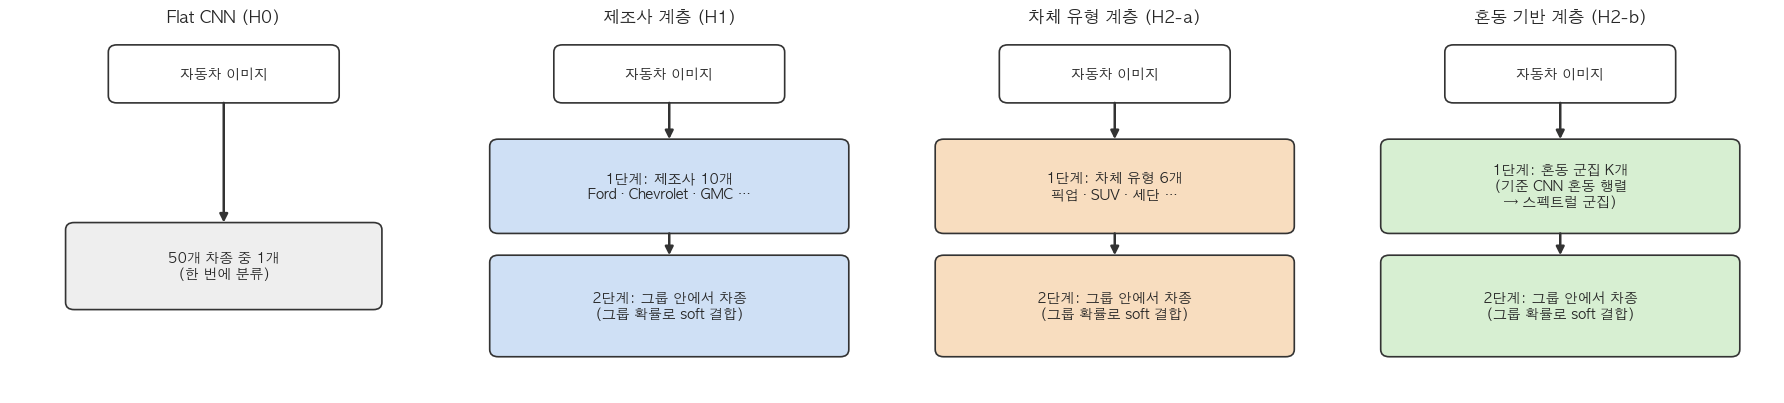

In [30]:
from matplotlib.patches import FancyBboxPatch
def box(ax, x, y, w, h, text, fc):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", fc=fc, ec="#333", lw=1.2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=10)
def arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), zorder=5,
                arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#333", shrinkA=0, shrinkB=0))

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
specs = [("Flat CNN (H0)", None, "#EEE"), ("제조사 계층 (H1)", "제조사 10개\nFord · Chevrolet · GMC …", "#CFE0F5"),
         ("차체 유형 계층 (H2-a)", f"차체 유형 {sel.body_type.nunique()}개\n픽업 · SUV · 세단 …", "#F8DDBF"),
         ("혼동 기반 계층 (H2-b)", "혼동 군집 K개\n(기준 CNN 혼동 행렬\n→ 스펙트럴 군집)", "#D7EFD2")]
for ax, (t, stage1, fc) in zip(axes, specs):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off"); ax.set_title(t, fontsize=12)
    box(ax, 0.25, 0.82, 0.5, 0.12, "자동차 이미지", "#FFF")
    if stage1 is None:
        box(ax, 0.15, 0.25, 0.7, 0.2, "50개 차종 중 1개\n(한 번에 분류)", "#EEE"); arrow(ax, 0.5, 0.80, 0.5, 0.47)
    else:
        box(ax, 0.1, 0.46, 0.8, 0.22, "1단계: " + stage1, fc)
        box(ax, 0.1, 0.12, 0.8, 0.24, "2단계: 그룹 안에서 차종\n(그룹 확률로 soft 결합)", fc)
        arrow(ax, 0.5, 0.80, 0.5, 0.70); arrow(ax, 0.5, 0.44, 0.5, 0.38)
plt.tight_layout(); savefig("C_hypothesis_models"); plt.show()

## 5단계. 개선 전략 조사

| # | 전략 | 무엇을 하는가 | 우리 데이터의 어떤 문제를 푸는가 | 출처 |
|---|---|---|---|---|
| 1 | **계층형 분류 — 의미 계층과 시각 계층 비교** | 1단계에서 그룹(제조사 / 차체 유형 / 혼동 군집)을 예측하고, 2단계 그룹별 분류기 출력을 1단계 확률로 가중합한다(soft conditioning) | 많은 클래스 + 세밀한 분류. 비슷한 차끼리 묶은 그룹 안에서만 미세 차이를 학습한다 | Yan et al. (2015) HD-CNN: 혼동 행렬 기반 coarse 그룹 구성 |
| 2 | **클래스 균형 손실 / Focal loss** | 클래스 빈도의 역수(effective number)로 손실에 가중치를 주거나, 쉬운 샘플의 손실을 줄인다 | 50개 클래스의 큰 불균형(표 아래 수치). 소수 클래스의 재현율을 보완한다 | Cui et al. (2019); Lin et al. (2017) |

**계층형 모델의 누수 주의:** 2단계 학습에 1단계의 *학습 데이터 예측값*을 쓰면 과적합된 확률이 들어간다. 그래서 1단계를 고정하거나 out-of-fold 예측을 쓴다.

In [31]:
display(Markdown(f"> 전략 2가 다루는 불균형: 선정 50개 클래스의 최대/최소 비율 **{mx / mn:.1f}배** ({mx:,}장 / {mn:,}장)"))

> 전략 2가 다루는 불균형: 선정 50개 클래스의 최대/최소 비율 **26.2배** (6,895장 / 263장)

## 예비 평가 계획

- **분할:** 계층화 70/15/15. md5 중복 그룹은 같은 분할에만 넣는다(B-3). seed는 3개 이상 반복한다.
- **지표**

| 지표 | 왜 필요한가 |
|---|---|
| Top-1 / Top-3 정확도 | 기본 성능 |
| **Macro-F1** (주 지표) | 불균형 때문에 정확도는 큰 클래스(예: civic, mustang) 성능에 끌려간다. 클래스를 동등하게 평가한다 |
| 클래스별 precision · recall · F1 | 소수 클래스와 형제차 클래스를 개별 확인한다 |
| 1단계 정확도 (제조사 / 차체 유형 / 군집) | 계층 모델에서 오류가 어느 단계에서 생기는지 분해한다 |
| **계층 오류 거리** | 오답이 같은 차체 유형·제조사 안에서 났는지 → "더 나은 실수" |
| 혼동 행렬 (차체 유형 순 정렬) | H0 검증: 오분류가 같은 차체 유형 블록에 몰리는가 |
| 학습·검증 곡선 | 과적합 확인 |
| 정성 분석 + Grad-CAM | H2 기각 시 CNN이 엠블럼을 보는지 확인 |

- **개선 판단 기준:** 같은 테스트 세트에서 Macro-F1이 기준 모델보다 개선되는지 본다. seed 간 표준편차보다 큰 차이만 "개선"으로 인정한다.

## 6단계. 시연 시나리오

| 항목 | 내용 |
|---|---|
| **대상 사용자** | 중고차 매물이나 길에서 본 차의 차종이 궁금한 일반 사용자 |
| **입력** | 50개 차종 중 하나가 찍힌 사진 (VMMRdb 테스트 이미지 또는 직접 찍은 사진) |
| **출력** | 1단계 그룹 확률(제조사 또는 차체 유형) → 차종 Top-3와 신뢰도 |

**시연 흐름**
1. 사진을 업로드한다.
2. 네 모델(Flat / 제조사 계층 / 차체 유형 계층 / 혼동 기반 계층)의 예측을 **나란히** 보여준다.
3. 계층 모델은 "1단계에서 어디로 보냈는지 → 2단계에서 무엇을 골랐는지"를 화면에 표시한다.
4. 준비한 사례 4종을 차례로 보여준다.
   - (a) 모두 맞히는 쉬운 차
   - (b) **형제차**: Silverado vs Sierra 1500 → 제조사 계층이 1단계에서 틀리는 장면
   - (c) **소수 클래스** → 가중 손실 적용 전후 비교
   - (d) 같은 차를 **앞/옆**에서 찍은 사진 → 시점에 따라 계층의 이득이 달라지는 장면
5. 마지막에 클래스별 F1 막대와 혼동 행렬(기준 vs 최종)로 개선 결과를 요약한다.

**범위 밖 입력** (50개에 없는 차, 차가 아닌 사진): 최고 확률이 임계값 미만이면 "학습된 차종이 아닐 수 있음"으로 안내한다.

## 참고문헌

1. Tafazzoli, F., Frigui, H., & Nishiyama, K. (2017). *A Large and Diverse Dataset for Improved Vehicle Make and Model Recognition.* CVPR Workshops. — https://github.com/faezetta/VMMRdb
2. Yang, L., Luo, P., Loy, C. C., & Tang, X. (2015). *A Large-Scale Car Dataset for Fine-Grained Categorization and Verification.* CVPR. — https://mmlab.ie.cuhk.edu.hk/datasets/comp_cars/
3. Yan, Z., Zhang, H., Piramuthu, R., Jagadeesh, V., DeCoste, D., Di, W., & Yu, Y. (2015). *HD-CNN: Hierarchical Deep Convolutional Neural Networks for Large Scale Visual Recognition.* ICCV.
4. Cui, Y., Jia, M., Lin, T.-Y., Song, Y., & Belongie, S. (2019). *Class-Balanced Loss Based on Effective Number of Samples.* CVPR.
5. Lin, T.-Y., Goyal, P., Girshick, R., He, K., & Dollár, P. (2017). *Focal Loss for Dense Object Detection.* ICCV.
6. Selvaraju, R. R., et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization.* ICCV.

> 보고서에 넣기 전에 각 서지 정보(학회, 연도, 저자)를 원문으로 한 번 더 확인할 것.